In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql

from datetime import datetime
from scipy.optimize import least_squares
from scipy.stats import norm
from typing import Optional, List, Tuple

# Functions

In [2]:
# ---------- Data -------------------------------------------------------------

def subset_expiries(df: pd.DataFrame, num_exp: int, min_days_to_exp: int = 7) -> pd.DataFrame:
    """
    Subset option chains data based on expiry dates.
    
    Args:
        df (pd.DataFrame):      Option chains data.
        num_exp (int):          Number of expiries to keep in the subset.
        min_days_to_exp (int):  Minimum number of days to the closest expiry.

    Returns:
        pd.DataFrame containing only the relevant expiries.
    """
    as_of = pd.to_datetime(df["date"].max()).tz_convert("UTC")
    all_expiries = df["expiry"].unique().tolist()
    expiries_subset = []
    for expiry in all_expiries:
        t_days = int(max(1, (pd.to_datetime(expiry, utc = True) - as_of).days))
        if t_days >= min_days_to_exp and len(expiries_subset) < num_exp:
            expiries_subset.append(expiry)
        if len(expiries_subset) == num_exp:
            exit
    first_expiry = expiries_subset[0]
    last_expiry = expiries_subset[-1]
    df = df[(df["expiry"] >= first_expiry) & (df["expiry"] <= last_expiry)]
    return df

def clean_data(df: pd.DataFrame, tick: float = 0.01, min_oi: int = 10, age_hours: int = 48) -> pd.DataFrame:
    """
    Clean data and remove invalid & illiquid quotes.
    
    Args:
        df (pd.DataFrame):  Option chains data.
        tick (float):       Minimum tick, 0.01 default for equity options. 
        min_oi (int):       Minimum open interest to identify illiquid quotes.
        age_hours (int):    Threshold to mark lastTradeDate as stale.

    Returns:
        pd.DataFrame containing only valid and liquid quotes from option chains data.
    """
    # Remove rows with non-positive prices/strikes or zero time
    df = df[(df["mid"] > 0) & (df["strike"] > 0) & (df["T"] > 0)]

    # Remove rows with missing IVs, bid or ask quotes
    df = df.dropna(subset = ["iv_mkt", "bid", "ask"])

    # Remove rows with obviously broken IVs: negative/zero, or absurdly high (> 500%)
    df.loc[df["iv_mkt"] <= 0, "iv_mkt"] = np.nan
    df.loc[df["iv_mkt"] > 5.0, "iv_mkt"] = np.nan
    df = df.dropna(subset = ["iv_mkt"]).reset_index(drop = True)

    # Identify invalid quotes: ask < bid, negative bid/ask, or zero book
    df["invalid_quote"] = ((df["ask"] < df["bid"]) | 
                           (df["bid"] < 0) | (df["ask"] <= 0) | 
                           ((df["bid"] == 0) & (df["ask"] == 0)))

    # Identify locked quotes with no liquidity: bid = ask & volume = 0 & very low OI
    df["locked_no_liquidity"] = ((df["ask"] - df["bid"] <= tick + 1e-12) & 
                                 (df["volume"].fillna(0) == 0) & 
                                 (df["openInterest"].fillna(0) < min_oi))
    
    # Identify stale quotes ("too old") that were last traded over age_hours since as_of
    df["stale_age"] = ((df["quote_age_hours"] > age_hours))

    # Drop these quotes
    df["drop"] = df[["invalid_quote", "locked_no_liquidity", "stale_age"]].any(axis=1)
    df = df[~df["drop"]]
    df = df.drop(columns=["invalid_quote", "locked_no_liquidity", "stale_age", "drop"])

    return df

def most_liquid_quotes(df: pd.DataFrame, spread_width: float = 0.25) -> pd.DataFrame:
    """
    Only keep the most liquid part of the option chains: ATM +/- 50%.
    
    Args:
        df (pd.DataFrame):      Option chains data.
        spread_width (float):   Width factor to maintain a reasonable bid–ask spread. 

    Returns:
        pd.DataFrame containing onlt the most liquid part of the option chains.
    """

    # Forward price
    df["F"] = df["underlying"] * np.exp((df["rate"] - df["div_yield"]) * df["T"])

    # Keep only strikes within +/-50% of forward
    df = df[(df["strike"] >= 0.5 * df["F"]) & (df["strike"] <= 1.5 * df["F"])]

    # Reasonable bid–ask spread
    df = df[((df["ask"] - df["bid"]) / df["mid"]) < spread_width]
    
    return df

def compute_trading_days_to_exp(row: pd.Series) -> int:
    """
    Compute the number of NYSE trading days between the option quote date and its expiry.
    
    Args:
        row (pd.Series):    A row of the option chains DataFrame representing an option. 
                            Must contain columns "date", "T_days".

    Returns:
        int that is the number of trading days between quote date & expiry date for the option of interest.
    """
    date_row = pd.to_datetime(row["date"]).tz_convert("UTC")
    today_row = ql.Date(date_row.day, date_row.month, date_row.year)
    T_days_row = int(row["T_days"])
    expiry_row = today_row + T_days_row
    cal = ql.UnitedStates(ql.UnitedStates.NYSE)
    return cal.businessDaysBetween(today_row, expiry_row)

# ---------- Fit Heston Model -------------------------------------------------

def build_vanilla_instruments(df: pd.DataFrame, today: ql.Date) -> List[ql.VanillaOption]:
    """
    Args:
        df (pd.DataFrame):  Option chains data.
        today (ql.Date):    Evaluation date.

    Returns:
        List of ql.VanillaOption objects corresponding to options available in chains.
    """

    options = []
    for _, df_row in df.iterrows():
        
        # Maturity
        T_days = int(max(1, (pd.to_datetime(df_row["expiry"]) - pd.to_datetime(df_row["date"])).days))
        maturity = today + T_days  # or cal.advance(today, T_days, ql.Days)
        exercise = ql.EuropeanExercise(maturity)

        # Payoff
        payoff = ql.PlainVanillaPayoff(ql.Option.Call if str(df_row["type"]).lower().startswith('c') else ql.Option.Put, float(df_row["strike"]))
        
        # Option Specification
        opt = ql.VanillaOption(payoff, exercise)
        options.append(opt)
    
    return options

def bs_price_vega(df: pd.DataFrame, options: List[ql.VanillaOption], S_q: ql.QuoteHandle,
                  r_ts: ql.YieldTermStructureHandle, q_ts: ql.YieldTermStructureHandle) -> pd.DataFrame:
    """
    Compute the Black-Scholes-Merton option price & vega for each quote in the options chain.
    
    Args:
        df (pd.DataFrame):                      Option chains data.
        options (List[ql.VanillaOption]):       List of ql.VanillaOption objects corresponding to option chains.
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
    
    Returns:
        pd.DataFrame with the option chains data and two new columns containing the Black-Scholes-Merton 
        option price ("bs_price") and corresponding vega ("vega") for each option.
    """

    bs_prices = []
    bs_vegas  = []
    bs_iv = []

    df = df.reset_index()
    for i, df_row in df.iterrows():

        # Build Volatility Curve
        sigma = float(df_row["iv_mkt"])
        vol_curve = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(0, ql.TARGET(), sigma, ql.Actual365Fixed()))

        # Build Black-Scholes-Merton process
        process = ql.BlackScholesMertonProcess(S_q, q_ts, r_ts, vol_curve)
        
        # Corresponding VanillaOption object
        option = options[i]

        # Black-Scholes analytic pricing engine
        engine = ql.AnalyticEuropeanEngine(process)
        option.setPricingEngine(engine)

        # Compute option price & vega
        bs_prices.append(option.NPV())
        bs_vegas.append(option.vega())

    df["bs_price"] = bs_prices
    df["vega"] = bs_vegas

    return df

# Calibration Weighting

def inverse_variance_weighting(bid: float, ask: float, S: float, K: float, T: float, r: float, q: float, iv: float, vega: float,
                               min_tick: float = 0.01, min_half_spread_iv: float = 0.0025, min_vega: float = 1e-5) -> float:
    """
    Give more weight to options with tight bid-ask spreads (as they are more reliable) in model calibration. 
    Convert each bid–ask spread in price space into a half-spread in IV space & assign weights using:
    w = 1/(spread^2).

    Args:
        bid (float):                    Bid quote.
        ask (float):                    Ask quote.
        S (float):                      Spot price.
        K (float):                      Strike price.
        T (float):                      Time to expiration.
        r (float):                      Risk-free rate.
        q (float):                      Dividend yield.
        iv (float):                     Implied volatility.
        vega (float):                   Vega of option.
        min_tick (float):               Tick floor for bid-ask spread.
        min_half_spread_iv (float):     Floor for IV half-spread.
        min_vega (float):               Vega threshold.
    
    Returns:
        float value for the inverse-variance weight. 
    """

    # Validate
    if not np.isfinite(bid) or not np.isfinite(ask) or ask <= bid or T <= 0 or iv <= 0:
        return np.nan
    
    # Price half-spread with tick floor
    half_spread_price = 0.5 * max(ask - bid, min_tick)

    # Convert price half-spread to IV half-spread
    if vega < min_vega:
        return np.nan
    half_spread_iv = half_spread_price / vega
    half_spread_iv = max(half_spread_iv, min_half_spread_iv)
    
    # Inverse-variance weight
    return 1.0 / (half_spread_iv ** 2)

def wing_damping_weighting(K: float, F: float, wing_lambda: float = 0.5) -> float:
    """
    Down-weight options far from forward to focus calibration on 'core' region where vol smile is anchored using:
    w = exp(-lambda * |k|).
    
    Args:
        K (float):              Strike price.
        F (float):              Forward price.
        wing_lambda (float):    Strength of exponential damping.
    
    Returns:
        float value for the wing-damping weight.
    """

    # Log-moneyness
    k = np.log(np.maximum(1e-12, (K / np.maximum(1e-12, F))))
    
    # Wing damping: as price moves away from strike, weight decays exponentially
    return np.exp(-wing_lambda * np.abs(k))

def calibration_weighting(df: pd.DataFrame, lambda_wing: float) -> pd.DataFrame:
    """
    Compute weight for each option that indicates how 'trustworthy' the quote is and how much it should 
    influence the volatility surface model calibration. Weights are normalized per expiry so one 
    maturity doesn't overwhelm model fit.

    Args:
        df (pd.DataFrame):      Option chains data.
        wing_lambda (float):    Rate of exponential decay in wing damping.

    Returns:
        pd.DataFrame containg option chains data with weight columns appended.
    """
    w_iv_list = []
    w_wing_list = []
    for _, df_row in df.iterrows():
        
        bid_w = df_row["bid"]
        ask_w = df_row["ask"]
        S_w = df_row["underlying"]
        K_w = df_row["strike"]
        T_w = df_row["T"]
        r_w = df_row["rate"]
        q_w = df_row["div_yield"]
        iv_w = df_row["iv_mkt"]
        vega_w = df_row["vega"]
        F_w = df_row["F"]
        
        # Inverse-IV-variance weight
        iv_weight = inverse_variance_weighting(bid_w, ask_w, S_w, K_w, T_w, r_w, q_w, iv_w, vega_w)
        w_iv_list.append(iv_weight)

        # Wing damping weight
        wd_weight = wing_damping_weighting(K_w, F_w, lambda_wing)
        w_wing_list.append(wd_weight)

    df["w_iv"] = w_iv_list
    df["w_wing"] = w_wing_list
    df["w"] = df["w_iv"] * df["w_wing"]
    df = df.dropna(subset = ["w_iv", "w_wing", "w"]).reset_index(drop = True)

    # Normalize Per Expiry
    df["w_norm"] = 0.0
    for exp, idx in df.groupby("expiry").groups.items():
        idx = list(idx)
        w_sum = df.loc[idx, "w"].sum()
        df.loc[idx, "w_norm"] = df.loc[idx, "w"] / (w_sum if w_sum > 0 else 1.0)
    
    return df

# Fit Model (Minimize Price RMSE)

def build_heston_engine(S_q: ql.QuoteHandle, r_ts: ql.YieldTermStructureHandle, q_ts: ql.YieldTermStructureHandle, 
                        kappa: float, theta: float, sigma: float, rho: float, v0: float) -> Tuple[ql.HestonModel, ql.AnalyticHestonEngine]:
    """
    Create a stochastic Heston model and pricing engine for asset & variance evolution under the risk-neutral 
    measure, given a set of parameters.

    Args:
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
        kappa (float):                          Mean reversion speed of variance.
        theta (float):                          Long-run variance level.
        sigma (float):                          Volatility of variance (vol of vol).
        rho (float):                            Correlation between asset returns and variance shocks.
        v0 (float):                             Initial variance.
        
    Returns:
        Tuple[ql.HestonModel, ql.AnalyticHestonEngine].
    """
    process = ql.HestonProcess(r_ts, q_ts, S_q, float(v0), float(kappa), float(theta), float(sigma), float(rho))
    model   = ql.HestonModel(process)
    engine  = ql.AnalyticHestonEngine(model)
    return model, engine

def fit_heston_ls(df: pd.DataFrame, options: List[ql.VanillaOption], S_q: ql.QuoteHandle, 
                  r_ts: ql.YieldTermStructureHandle, q_ts: ql.YieldTermStructureHandle,
                  lb: List[float], ub: List[float]) -> Tuple:
    """
    Calibrates Heston model to option chains by finding the parameter vector that minimizes the weighted sum 
    of squared price errors via non-linear least squares.
    
    Args:
        df (pd.DataFrame):                      Option chains data.
        options (List[ql.VanillaOption]):       List of ql.VanillaOption objects corresponding to input option chains. 
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
        lb (List[float]):                       Lower bounds for Heston parameters: kappa, theta, sigma, rho, v0.
        ub (List[float]):                       Upper bounds for Heston parameters: kappa, theta, sigma, rho, v0.
    
    Returns:
        Tuple containing the fitted Heston parameters: kappa, theta, sigma, rho, v0.
    """

    prices_mkt = df["mid"].to_numpy(float)
    weights = df["w_norm"].to_numpy(float)

    # Residual function for least-squares
    def resid(params: list) -> list:
        
        kappa, theta, sigma, rho, v0 = params

        # Basic bounds inside residual (keeps optimizer sane)
        # if not (0.0 < kappa <= 15.0 and 1e-6 <= theta <= 1.0 and 0.05 <= sigma <= 2.0 and -0.999 < rho < 0.0 and 1e-6 <= v0 <= 1.0):
        #     return np.ones_like(prices_mkt) * 1e6
        
        # Create AnalyticHestonEngine for params
        _, engine = build_heston_engine(S_q, r_ts, q_ts, kappa, theta, sigma, rho, v0)

        # Set engine & get model prices
        model_prices = np.empty_like(prices_mkt)
        for i, opt in enumerate(options):
            opt.setPricingEngine(engine)
            model_prices[i] = float(opt.NPV())
        
        # Weighted residuals (absolute price)
        weighted_resid = np.sqrt(weights) * np.abs(model_prices - prices_mkt)
        return weighted_resid
    
    # Initial seeds
    atm_iv  = float(df["iv_mkt"].median())
    v0_seed = max(1e-4, atm_iv**2)
    x0 = np.array([2.0,  max(1e-4, (atm_iv*1.1)**2), 0.5, -0.5, v0_seed])

    # Minimize weighted sum of squared price errors via least squares
    res = least_squares(resid, x0, bounds = (np.array(lb), np.array(ub)), xtol = 1e-8, ftol = 1e-8, gtol = 1e-8, max_nfev = 400)

    # Parameters: kappa, theta, sigma, rho, v0
    return res.x

def compute_price_rmse(df: pd.DataFrame, options: List[ql.VanillaOption], engine: ql.AnalyticHestonEngine) -> float:
    """
    Evaluate the root mean square error between market price and model price.
    
    Args:
        df (pd.DataFrame):                  Option chains data.
        options (List[ql.VanillaOption]):   List of ql.VanillaOption objects corresponding to option chains. 
        engine (ql.AnalyticHestonEngine):   Calibrated Heston pricing engine.
    
    Returns:
        float value for price RMSE.
    """
    model_option_prices = []
    for opt in options:
        opt.setPricingEngine(engine)
        model_option_prices.append(float(opt.NPV()))
    model_option_prices = np.array(model_option_prices)
    market_option_prices = df["mid"].to_numpy(float)
    return float(np.sqrt(np.nanmean((model_option_prices - market_option_prices)**2)))

# Compute Model Price & Implied Volatility

def compute_model_prices_and_ivs(df: pd.DataFrame, engine: ql.AnalyticHestonEngine, today: ql.Date, 
                                 S_q: ql.QuoteHandle, r_ts: ql.YieldTermStructureHandle, 
                                 q_ts: ql.YieldTermStructureHandle) -> Tuple[List[float], List[float]]:
    """
    Compute Heston-derived prices and implied volatilities for input option chains.

    Args:
        df (pd.DataFrame):                      Option chains data.
        engine (ql.AnalyticHestonEngine):       Calibrated Heston pricing engine.
        today (ql.Date):                        Evaluation date.
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
        
    Returns:
        Tuple[List[float], List[float]] where the first list contains the Heston-derived option prices and 
        the second contains the corresponding model-derived implied volatilities.
    """

    # Build a flat BSM volatility curve with arbitrary seed (doesn't matter)
    vol_seed = ql.BlackConstantVol(today, ql.NullCalendar(), 0.20, ql.Actual365Fixed())
    vol_ts_seed = ql.BlackVolTermStructureHandle(vol_seed)
    bsm_process = ql.BlackScholesMertonProcess(S_q, q_ts, r_ts, vol_ts_seed)

    bs_ivs = []
    model_prices = []
    for _, df_row in df.iterrows():
        
        # Maturity
        T_days = int(max(1, (pd.to_datetime(df_row["expiry"]) - pd.to_datetime(df_row["date"])).days))
        maturity = today + T_days
        exercise = ql.EuropeanExercise(maturity)

        # Create option
        option_type = ql.Option.Call if str(df_row["type"]).lower().startswith('c') else ql.Option.Put
        option = ql.VanillaOption(ql.PlainVanillaPayoff(option_type, float(df_row["strike"])), exercise)

        # Price option using calibrated Heston model
        option.setPricingEngine(engine)
        price_model = float(option.NPV())
        model_prices.append(price_model)

        # Compute implied volatility
        # iv = option.impliedVolatility(price_model, bsm_process, 1e-8, 100, 1e-6, 6.0)
        iv = option.impliedVolatility(price_model, bsm_process, 1e-8, 500, 1e-6, 10.0)
        bs_iv = float(iv)
        bs_ivs.append(bs_iv)
    
    return model_prices, bs_ivs

def model_prices_and_ivs(df: pd.DataFrame, engine: ql.AnalyticHestonEngine, today: ql.Date, S_q: ql.QuoteHandle, 
                         r_ts: ql.YieldTermStructureHandle, q_ts: ql.YieldTermStructureHandle) -> pd.DataFrame:
    """
    Compute Heston-derived prices and implied volatilities for input option chains.

    Args:
        df (pd.DataFrame):                      Option chains data.
        engine (ql.AnalyticHestonEngine):       Calibrated Heston pricing engine.
        today (ql.Date):                        Evaluation date.
        S_q (ql.QuoteHandle):                   Spot quote.
        r_ts (ql.YieldTermStructureHandle):     Risk-free curve.
        q_ts (ql.YieldTermStructureHandle):     Dividend curve.
        
    Returns:
        pd.DataFrame of option chains data with with two additional columns ("price_model", "iv_model")
        containing the Heston-derived prices and implied volatilities, respectively. 
    """
    model_prices, model_ivs = compute_model_prices_and_ivs(df, engine, today, S_q, r_ts, q_ts)
    df["price_model"] = model_prices
    df["iv_model"] = model_ivs
    return df

def compute_residuals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate the weighted residuals for prices and IVs.
    
    Args:
        df (pd.DataFrame):  Option chains data containing model prices & IVs.
    
    Returns:
        pd.DataFrame of option chains data with two additional columns ("price_resid", "iv_resid") 
        containing the computed weighted price and IV residuals, respectively.
    """
    
    weights = df["w_norm"].to_numpy(float)
    prices_mkt = df["mid"].to_numpy(float)
    prices_model = df["price_model"].to_numpy(float)
    iv_mkt = df["iv_mkt"].to_numpy(float)
    iv_model = df["iv_model"].to_numpy(float)
    
    # Price Residuals
    price_residuals = np.sqrt(weights) * np.abs(prices_model - prices_mkt)
    df["price_resid"] = price_residuals

    # IV Residuals
    iv_residuals = np.sqrt(weights) * np.abs(iv_model - iv_mkt)
    df["iv_resid"] = iv_residuals
    
    return df

# ---------- Simulate Volatility Paths ----------------------------------------

def simulate_heston_paths(process: ql.HestonProcess, maturity: float, n_steps: int, n_paths: int, 
                          seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate price & instantaneous variance paths based on the stochastic dynamics of (S_t, v_t) from the calibrated 
    Heston process using Monte Carlo simulations. 
    NOTE: QuantLib uses Quadratic Exponential discretization for the variance process & log-Euler discretization for the asset price.
    
    Args:
        process : ql.HestonProcess     
            Calibrated Heston process describing the stochastic dynamics of (S_t, v_t).
        maturity : float               
            The simulation time horizon T expressed as a year fraction (e.g. 0.25 = 3 months).
            If starting from calendar dates, convert with a day counter: T = daycounter.yearFraction(today, expiry_date).
        n_steps : int                  
            Number of time steps between 0 and T in the Monte Carlo grid (dt = maturity / n_steps).
        n_paths : int                  
            Number of independent Monte Carlo sample paths to generate.
        seed : int (default = 42)                     
            Random seed for QuantLib's pseudo-random sequence generator, ensuring reproducibility of the simulated paths.

    Returns:
        t_grid : np.ndarray, shape (n_steps + 1,)
            Simulation grid time steps from 0 to T, as year fractions.
        S_paths_sim : np.ndarray, shape (n_paths, n_steps + 1)
            Simulated price paths of the underlying asset S_t.
        v_paths_sim : np.ndarray, shape (n_paths, n_steps + 1)
            Simulated instantaneous variance paths v_t.
    """
    # Generate a multivariate Gaussian path consistent with the SDE dynamics for Heston process & time grid
    times = ql.TimeGrid(maturity, n_steps)
    # Gaussian sequence generator
    n_factors = process.factors() # 2 factors: S_t, v_t
    dimension = n_factors * n_steps
    uniform_seq_gen = ql.UniformRandomSequenceGenerator(dimension, ql.UniformRandomGenerator(seed))
    gaussian_seq_gen = ql.GaussianRandomSequenceGenerator(uniform_seq_gen)
    # Multi-path generator
    path_gen = ql.GaussianMultiPathGenerator(process, times, gaussian_seq_gen, False)
    S_paths_sim = np.zeros((n_paths, n_steps + 1))
    v_paths_sim = np.zeros((n_paths, n_steps + 1))
    for i in range(n_paths):
        sample = path_gen.next()
        multi_path = sample.value()
        S_paths_sim[i, :] = [multi_path[0][j] for j in range(len(times))]
        v_paths_sim[i, :] = [multi_path[1][j] for j in range(len(times))]
    t_grid = np.array([times[j] for j in range(len(times))])
    return t_grid, S_paths_sim, v_paths_sim

def mc_option_price_est(spot_prices_T: np.ndarray, strike: float, T_exercise: float, r_ts: ql.YieldTermStructureHandle, 
                        n_paths: int, opt_type: str, ci_level: float = 0.95) -> Tuple[float, float, float]:
    """
    Compute the option price estimate and confidence interval across the Monte Carlo simulated spot price paths at expiry.
    
    Args:
        spot_prices_T : np.ndarray (n_paths,)            
            Simulation spot prices at maturity/exercise (T).
        strike : float        
            Option strike price.
        T_exercise : float         
            Time to maturity/exercise, as a year fraction.
        r_ts : ql.YieldTermStructureHandle
            Risk-free rate QuantLib term structure.
        n_paths : int
            Number of Monte Carlo sample paths.
        opt_type : str (default = None)    
            Option type of data to be plotted: specify "c" for calls and "p" for puts.
        ci_level : float (default = 0.95)
            Confidence interval level, as a decimal (e.g. 95% = 0.95).
    
    Returns:
        mc_mean : float
            Option price estimate at maturity/exercise.
        ci_lower : float
            Lower bound of the confidence interval for the option price estimate at maturity/exercise.
        ci_upper : float
            Upper bound of the confidence interval for the option price estimate at maturity/exercise.
    """
    payoffs = np.maximum(spot_prices_T - strike, 0.0) if opt_type.lower() == "c" else np.maximum(strike - spot_prices_T, 0.0)
    discount_factor = r_ts.discount(T_exercise)
    discounted_payoffs = discount_factor * payoffs
    mc_mean = discounted_payoffs.mean()
    mc_std  = discounted_payoffs.std(ddof = 1)
    z = norm.ppf(1 - ci_level / 2)
    ci_lower = float(mc_mean - z * mc_std / np.sqrt(n_paths))
    ci_upper = float(mc_mean + z * mc_std / np.sqrt(n_paths))
    return mc_mean, ci_lower, ci_upper

# ---------- Plots ------------------------------------------------------------

def plot_prices(df: pd.DataFrame, ticker: str, n_exp: int, option_type: Optional[str] = None, expiry: Optional[str] = None):
    """
    Plot model price vs market price for each strike and the corresponding residuals.
    
    Args:
        df (pd.DataFrame):              Option chains data containing model prices & IVs.
        ticker (str):                   Stock ticker symbol.
        n_exp (int):                    Number of expiries included in options chain.
        option_type (Optional[str]):    Option type of data to be plotted. Default value is None, indicating both calls & puts. 
                                        Specify "c" for calls only and "p" for puts only.
        expiry (Optional[str]):         If the data contains only a single expiry, specify this date as a string. 
                                        Otherwise, the default value is None.
    """

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

    # Model Price vs Market Price
    ax[0].scatter(df['strike'], df['mid'], label = 'Market', color = 'c', alpha = 0.5, s = 50)
    ax[0].scatter(df['strike'], df['price_model'], label = 'Heston', color = 'm', alpha = 0.5, s = 30)
    ax[0].set_xlabel("Strike")
    ax[0].set_ylabel("Price")
    ax[0].set_title(f"Option Price: Model vs Market")
    ax[0].legend()

    # Weighted Residuals
    ax[1].scatter(df['strike'], df['price_resid'], color = 'r')
    ax[1].set_xlabel("Strike")
    ax[1].set_ylabel("Absolute Price")
    ax[1].set_title(f"Weighted Residuals")

    # Option Type
    if option_type is not None: 
        option_type_str = "Calls" if option_type.lower() == "c" else "Puts"
    else:
        option_type_str = "Options"
    
    # Figure Title
    if expiry is not None:
        expiry_datetime = datetime.strptime(expiry, "%Y-%m-%d %H:%M:%S%z")
        expiry_date_str = expiry_datetime.date().strftime("%Y-%m-%d")
        fig_title = f"{ticker} {option_type_str}, {expiry_date_str} Expiry"
    else:
        fig_title = f"{ticker} {option_type_str} Across {n_exp} Expiries"
    
    fig.suptitle(fig_title, fontsize=18)
    plt.show()

def plot_iv(df: pd.DataFrame, ticker: str, n_exp: int, option_type: Optional[str] = None, expiry: Optional[str] = None):
    """
    Plot model IV vs market IV for each strike and the corresponding residuals.
    
    Args:
        df (pd.DataFrame):              Option chains data containing model prices & IVs.
        ticker (str):                   Stock ticker symbol.
        n_exp (int):                    Number of expiries included in options chain.
        option_type (Optional[str]):    Option type of data to be plotted. Default value is None, indicating both calls & puts. 
                                        Specify "c" for calls only and "p" for puts only.
        expiry (Optional[str]):         If the data contains only a single expiry, specify this date as a string. 
                                        Otherwise, the default value is None.
    """

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

    # Model IV vs Market IV
    ax[0].scatter(df['strike'], df['iv_mkt'], label = 'Market', color = 'c', alpha = 0.5, s = 50)
    ax[0].scatter(df['strike'], df['iv_model'], label = 'Heston', color = 'm', alpha = 0.5, s = 30)
    ax[0].set_xlabel("Strike")
    ax[0].set_ylabel("Implied Volatility")
    ax[0].set_title(f"Implied Volatility: Model vs Market")
    ax[0].legend()

    # Weighted Residuals
    ax[1].scatter(df['strike'], df['iv_resid'], color = 'r')
    ax[1].set_xlabel("Strike")
    ax[1].set_ylabel("Implied Volatility")
    ax[1].set_title(f"Weighted Residuals")

    # Option Type
    if option_type is not None: 
        option_type_str = "Calls" if option_type.lower() == "c" else "Puts"
    else:
        option_type_str = "Options"
    
    # Figure Title
    if expiry is not None:
        expiry_datetime = datetime.strptime(expiry, "%Y-%m-%d %H:%M:%S%z")
        expiry_date_str = expiry_datetime.date().strftime("%Y-%m-%d")
        fig_title = f"{ticker} {option_type_str}, {expiry_date_str} Expiry"
    else:
        fig_title = f"{ticker} {option_type_str} Across {n_exp} Expiries"
    
    fig.suptitle(fig_title, fontsize=18)
    plt.show()

def plot_sim_paths(t_grid: np.ndarray, spot_paths: np.ndarray, var_paths: np.ndarray, 
                   spot_p05: np.ndarray, spot_p50: np.ndarray, spot_p95: np.ndarray,
                   var_p05: np.ndarray, var_p50: np.ndarray, var_p95: np.ndarray, 
                   ticker: str, expiry: str, option_type: Optional[str] = None):
    """
    Plot the first 50 spot price paths & variance paths simulated under today’s calibrated risk-neutral Heston dynamics
    for options with a specified expiry.
    
    Args:
        t_grid : np.ndarray            
            Simulation grid time steps from 0 to T, as year fractions.
        spot_paths : np.ndarray        
            Simulated spot price paths of the underlying asset.
        var_paths : np.ndarray         
            Simulated instantaneous variance paths.
        spot_p05 : np.ndarray
            5% quantile band for the simulated Heston spot paths.
        spot_p50 : np.ndarray
            50% quantile band for the simulated Heston spot paths.
        spot_p95 : np.ndarray
            95% quantile band for the simulated Heston spot paths.
        var_p05 : np.ndarray
            5% quantile band for the simulated Heston variance paths.
        var_p50 : np.ndarray
            50% quantile band for the simulated Heston variance paths.
        var_p95 : np.ndarray
            95% quantile band for the simulated Heston variance paths.
        ticker : str                   
            Underlying ticker symbol.
        expiry : str                  
            Option expiry date as a string.
        option_type : Optional[str] (default = None)    
            Option type of data to be plotted. Specify "c" for calls and "p" for puts. None indicates both calls & puts.
    """
    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 8))

    # Spot Paths
    for i in range(50):
        ax[0].plot(t_grid, spot_paths[i, :], alpha = 0.4)
    ax[0].plot(t_grid, spot_p50, color = "red", label = "Median")
    ax[0].fill_between(t_grid, spot_p05, spot_p95, color = "grey", alpha = 0.25, label = "5–95% Percentile")
    ax[0].set_xlabel("Time (years)")
    ax[0].set_ylabel("Spot Price")
    ax[0].set_title("Simulated Heston Spot Paths")
    ax[0].legend()

    # Variance Paths
    for i in range(50):
        ax[1].plot(t_grid, var_paths[i, :], alpha = 0.4)
    ax[1].plot(t_grid, var_p50, color = "red", label = "Median")
    ax[1].fill_between(t_grid, var_p05, var_p95, color = "grey", alpha = 0.25, label = "5–95% Percentile")
    ax[1].set_xlabel("Time (years)")
    ax[1].set_ylabel("Variance")
    ax[1].set_title("Simulated Variance Paths")
    ax[1].legend()
    
    # Figure Title
    if option_type is not None: 
        option_type_str = "Calls" if option_type.lower() == "c" else "Puts"
    else:
        option_type_str = "Options"
    expiry_datetime = datetime.strptime(expiry, "%Y-%m-%d %H:%M:%S%z")
    expiry_date_str = expiry_datetime.date().strftime("%Y-%m-%d")
    fig_title = f"{ticker} {option_type_str}, {expiry_date_str} Expiry"
    
    fig.suptitle(fig_title, fontsize=18)
    plt.show()

def compare_prices(df: pd.DataFrame, ticker: str, expiry: str, option_type: Optional[str] = None):
    """
    Plot market option price vs estimated option price (via Monte Carlo simulation) for each strike price.
    
    Args:
        df (pd.DataFrame):              Option chains data. Must contain columns: 
                                        ['strike', 'mid', 'mc_price', 'ci_lower', 'ci_upper'].
        ticker (str):                   Stock ticker symbol.
        expiry (str):                   Option expiry date as 'YYYY-MM-DD'.
        option_type (Optional[str]):    Option type of data to be plotted. Default value is None, indicating both calls & puts. 
                                        Specify "c" for calls only and "p" for puts only.
    """
    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 8))

    # Market Price vs MC Estimate
    ax[0].plot(df['strike'], df['mid'], color = 'g', alpha = 0.5, linestyle='--')
    ax[0].scatter(df['strike'], df['mid'], label = 'Market', color = 'g', alpha = 0.5, s = 30)
    ax[0].plot(df['strike'], df['mc_price'], color = 'r', alpha = 0.5, linestyle='--')
    ax[0].scatter(df['strike'], df['mc_price'], label = 'MC Estimate', color = 'r', alpha = 0.5, s = 30)
    ax[0].fill_between(df['strike'], df['ci_lower'], df['ci_upper'], color = 'b', alpha = 0.25, label = "95% Confidence Interval")
    ax[0].set_xlabel("Strike")
    ax[0].set_ylabel("Price")
    ax[0].set_title(f"Option Price: Market vs Monte Carlo Estimate")
    ax[0].legend()

    # Residuals
    residuals = df['mid'] - df['mc_price']
    ax[1].scatter(df['strike'], residuals)
    ax[1].set_xlabel("Strike")
    ax[1].set_ylabel("Market Price - Model Price")
    ax[1].set_title(f"Residuals")

    # Figure Title
    if option_type is not None: 
        option_type_str = "Calls" if option_type.lower() == "c" else "Puts"
    else:
        option_type_str = "Options"
    expiry_datetime = datetime.strptime(expiry, "%Y-%m-%d %H:%M:%S%z")
    expiry_date_str = expiry_datetime.date().strftime("%Y-%m-%d")
    fig_title = f"{ticker} {option_type_str}, {expiry_date_str} Expiry"

    fig.suptitle(fig_title, fontsize = 18)
    plt.show()


# Data

In [3]:
# ---------- Inputs ----------

TICKER          = "SPY"
AS_OF           = "20251117"    # Date as 'YYYYMMDD'
N_EXP           = 15            # Number of expiries
MIN_DAYS_TO_EXP = 7

# ---------- Parameters ----------

MIN_TICK        = 0.01          # Equity options minimum tick
MIN_OI          = 10            # Minimum openInterest
AGE_HOURS       = 48            # Threshold to mark lastTradeDate as stale
MAX_SPREAD_BPS  = 75.0          # Maximum bid-ask spread width as basis points of mid: spread_bps = ((ask - bid) / mid) * 10000
TOL_MONEYNESS   = 0.005         # Maximum distance of a real contract from moneyness bin
TOL_DAYS        = 3             # Maximum distance of a real contract from tenor bin
LAMBDA_WING     = 0.5

# Heston Parameter Bounds
KAPPA_LB        = 0.05
KAPPA_UB        = 30.0
THETA_LB        = 1e-6
THETA_UB        = 2.0
SIGMA_LB        = 0.05
SIGMA_UB        = 5.00
RHO_LB          = -0.999
RHO_UB          = -1e-3
V0_LB           = 1e-6
V0_UB           = 1.0
PARAM_LB        = [KAPPA_LB, THETA_LB, SIGMA_LB, RHO_LB, V0_LB]
PARAM_UB        = [KAPPA_UB, THETA_UB, SIGMA_UB, RHO_UB, V0_UB]

In [4]:
# ---------- Load Raw Data ----------

# Load raw option chains data from file
root_dir = os.path.abspath(os.path.join(".."))
data_dir = os.path.join(root_dir, "data", "options")
data_file = f"{TICKER}_{AS_OF}.csv"
data_path = os.path.join(data_dir, data_file)
raw_data = pd.read_csv(data_path)

# Subset to relevant expiries
chains_df = subset_expiries(raw_data, N_EXP, MIN_DAYS_TO_EXP)

# ---------- Pre-build QL objects that don't change ----------

# Evaluation date (use latest date in the panel)
date = pd.to_datetime(chains_df["date"].max()).tz_convert("UTC")
today = ql.Date(date.day, date.month, date.year)
ql.Settings.instance().evaluationDate = today
cal = ql.UnitedStates(ql.UnitedStates.NYSE)

# Spot, risk-free, dividend yield
S0 = float(chains_df["underlying"].iloc[-1])
r  = float(chains_df["rate"].iloc[-1])
q  = float(chains_df["div_yield"].iloc[-1]) # TODO: HOW DOES FIT CHANGE FOR 0 DIVIDEND? 

# QuantLib handles
S_quote = ql.QuoteHandle(ql.SimpleQuote(S0))
r_curve = ql.YieldTermStructureHandle(ql.FlatForward(today, r, ql.Actual365Fixed(), ql.Continuous))
q_curve = ql.YieldTermStructureHandle(ql.FlatForward(today, q, ql.Actual365Fixed(), ql.Continuous))

# ---------- Clean Data ----------

# Drop bad quotes
chains_df = clean_data(chains_df, MIN_TICK, MIN_OI, AGE_HOURS)
chains_df = most_liquid_quotes(chains_df)

# Exclude ITM Options
chains_df["type"] = chains_df["type"].astype(str).str.lower()
chains_df.loc[chains_df["type"].str.startswith("c"), "type"] = "call"
chains_df.loc[chains_df["type"].str.startswith("p"), "type"] = "put"
chains_df = chains_df[((chains_df["type"] == "call") & (chains_df["strike"] >= S0)) | 
                      ((chains_df["type"] == "put") & (chains_df["strike"] <= S0))]

# Time to maturity as year fraction (Actual/365)
if "T" not in chains_df.columns:
    chains_df["T"] = (pd.to_datetime(chains_df["expiry"]) - pd.to_datetime(chains_df["date"])).dt.days.clip(lower = 0).astype(float) / 365.0

# Days to maturity
if "T_days" not in chains_df.columns:
    chains_df["T_days"] = (pd.to_datetime(chains_df["expiry"]) - pd.to_datetime(chains_df["date"])).dt.days.clip(lower = 0).astype(int)
    # T_days = int(max(1, (pd.to_datetime(df_row["expiry"]) - pd.to_datetime(df_row["date"])).days))
chains_df["trading_days_to_exp"] = chains_df.apply(compute_trading_days_to_exp, axis=1)

# Forward price
if "F" not in chains_df.columns:
    chains_df["F"] = chains_df["underlying"] * np.exp((chains_df["rate"] - chains_df["div_yield"]) * chains_df["T"])

# ---------- Subsets ----------

# All Expiries
all_chains = chains_df.copy()
all_calls = chains_df[chains_df["type"] == "call"]
all_puts = chains_df[chains_df["type"] == "put"]

# Single Expiry (2026-01-16)
EXPIRY = "2026-01-16 00:00:00+00:00"
chains_single_exp = chains_df[chains_df["expiry"] == EXPIRY]
calls_single_exp = chains_single_exp[chains_single_exp["type"] == "call"]
puts_single_exp = chains_single_exp[chains_single_exp["type"] == "put"]

# Simulate Heston SDE Dynamics

$\Large{\text{Heston SDE Dynamics:}}$

$$
\begin{aligned}
    dS_t &= (r - q) S_t \, dt + \sqrt{v_t} \, S_t \, dW_t^{(S)} \\
    dv_t &= \kappa \left( \theta- v_t \right) dt + \sigma \, \sqrt{v_t} \, dW_t^{(v)} \\
    dW_t^{(S)} \, dW_t^{(v)} &= \rho \, dt \\
\end{aligned}
$$

**Parameter set:** 

* $v_{0}$: Initial variance ($t = 0$).

* $\theta$: Long-run average variance of the price.

* $\kappa$: The rate at which $v_t$ reverts to $\theta$.

* $\sigma$: Volatility of volatility (variance of $v_t$).

* $\rho$: Correlation of the Weiner processes $W_t^{(S)}$, $W_t^{(v)}$.

## Single Expiry Calls (2026-01-16)

### Calibrate Heston

In [5]:
# ---------- Calibrate Heston ----------

# Calibration weighting
calls_list_single_exp = build_vanilla_instruments(calls_single_exp, today)
calls_single_exp = bs_price_vega(calls_single_exp, calls_list_single_exp, S_quote, r_curve, q_curve)
calls_single_exp = calibration_weighting(calls_single_exp, LAMBDA_WING)
calls_list_single_exp = build_vanilla_instruments(calls_single_exp, today)

# Fit Heston Model
kappa, theta, sigma, rho, v0 = fit_heston_ls(calls_single_exp, calls_list_single_exp, S_quote, r_curve, q_curve, PARAM_LB, PARAM_UB)
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()
rmse_price = compute_price_rmse(calls_single_exp, calls_list_single_exp, heston_pricing_engine)

# Compute Model Prices & IV
calls_single_exp = model_prices_and_ivs(calls_single_exp, heston_pricing_engine, today, S_quote, r_curve, q_curve)
calls_single_exp = compute_residuals(calls_single_exp)

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f}")
print(f"  theta = {float(theta):.8f}")
print(f"  sigma = {float(sigma):.8f}")
print(f"  rho   = {float(rho):.8f}")
print(f"  v0    = {float(v0):.8f}")
print(f"\nPrice RMSE: {float(rmse_price):.8f}")
print(f"Mean Option Price: {float(np.nanmean(calls_single_exp["mid"])):.8f}")

Calibrated Heston Parameters:
  kappa = 29.81164998
  theta = 0.06037001
  sigma = 4.28857568
  rho   = -0.70435931
  v0    = 0.00561116

Price RMSE: 0.01379670
Mean Option Price: 3.33258621


#### Plots

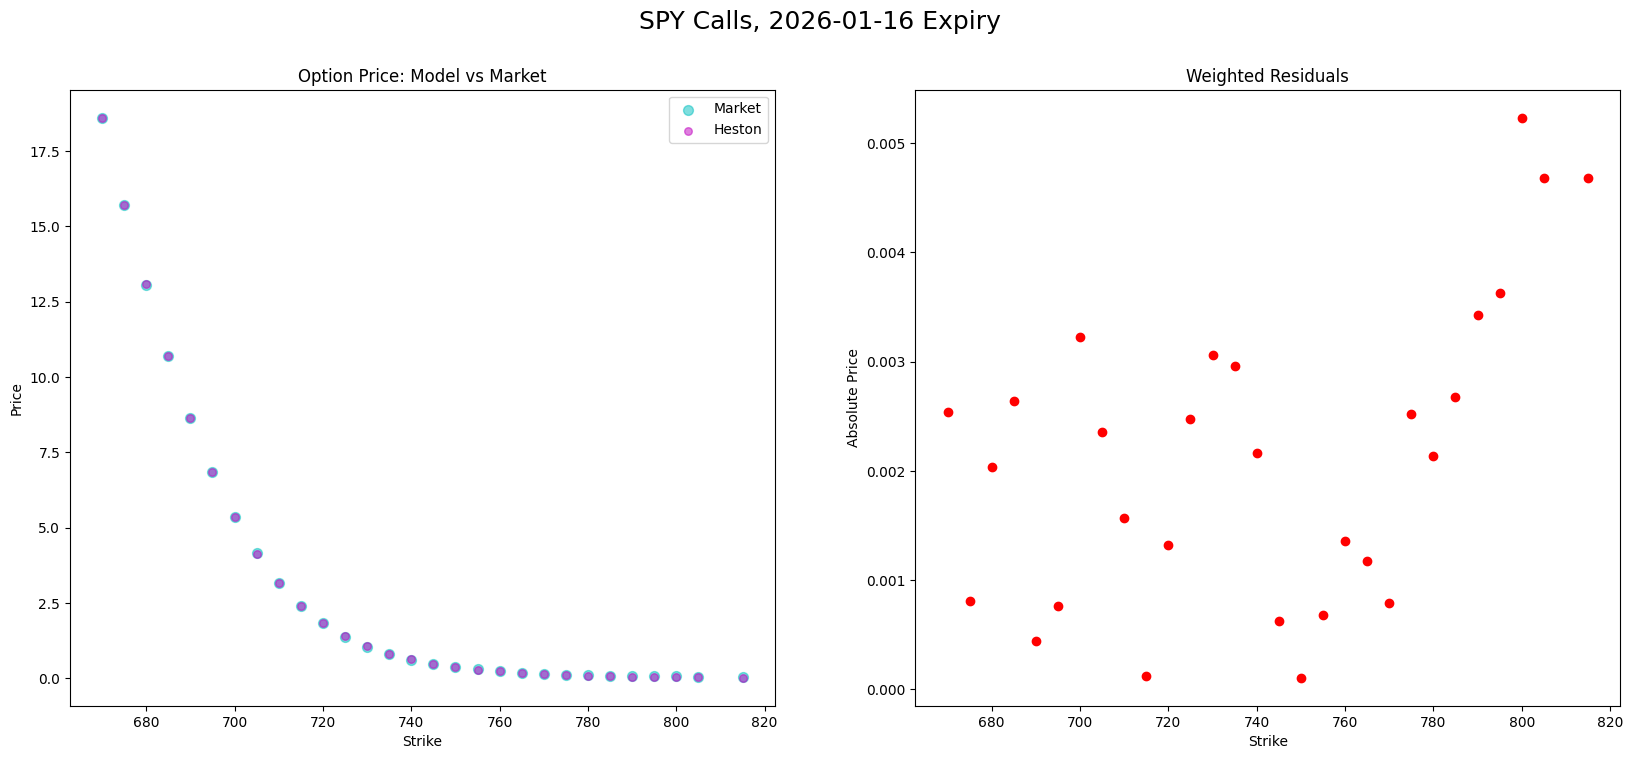

In [6]:
plot_prices(calls_single_exp, TICKER, N_EXP, "c", EXPIRY)

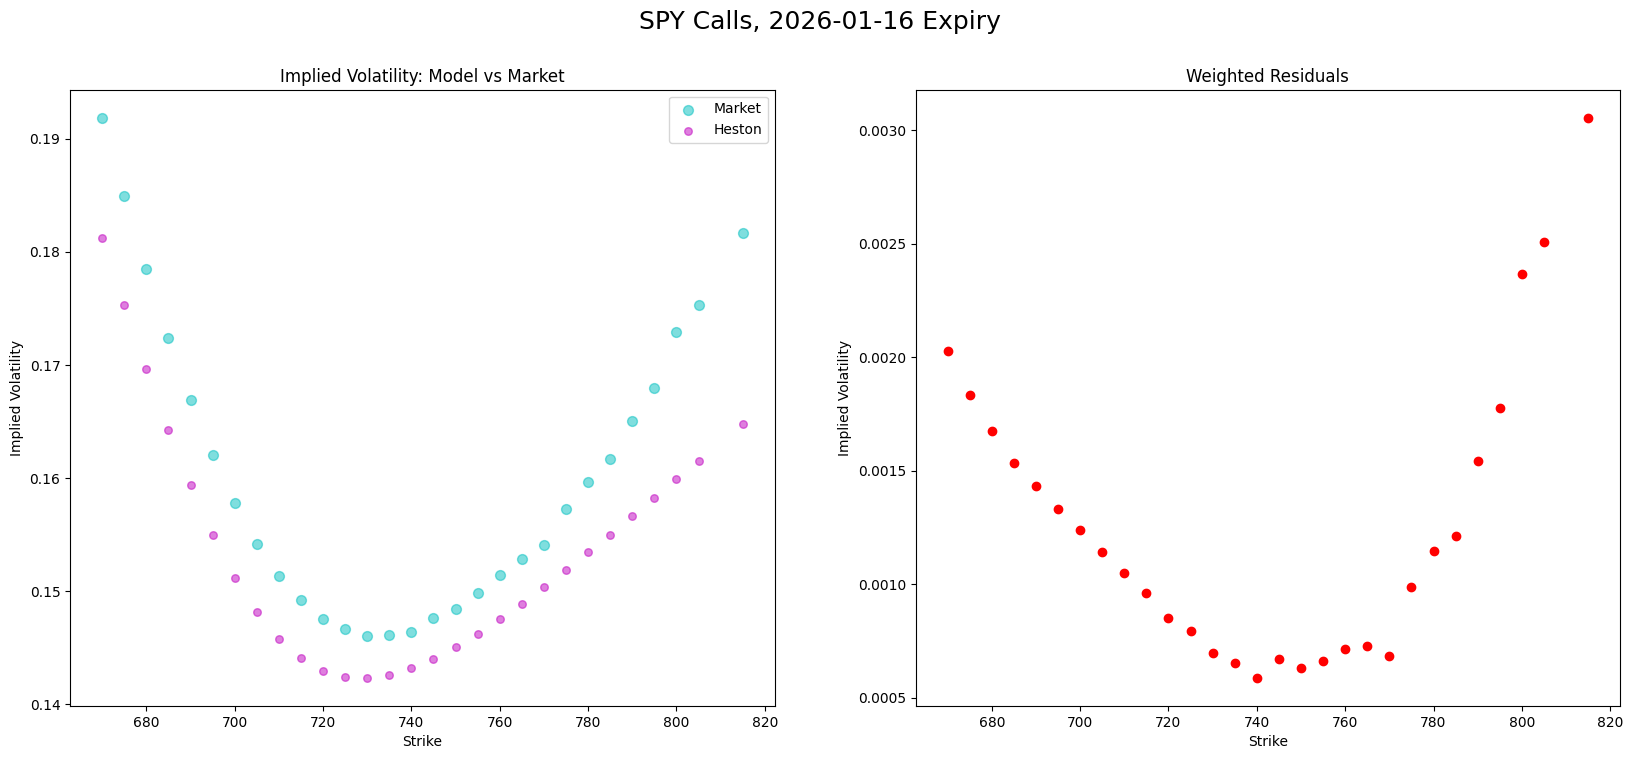

In [7]:
plot_iv(calls_single_exp, TICKER, N_EXP, "c", EXPIRY)

### Simulate Volatility Paths

In [8]:
# ---------- Simulate Volatility Paths from Calibrated Heston ----------

# Simulation horizon
T_sim = float(calls_single_exp["T"].max())

# Trading days to expiry
trading_days_to_exp = int(calls_single_exp["trading_days_to_exp"].max())

# Monte Carlo settings
N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
N_PATHS_MC = 10000                              # number of simulated paths

# Simulate under today’s calibrated risk-neutral Heston dynamics
time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
vol_paths = np.sqrt(v_paths)

# ---------- 5%–95% Quantile Bands ----------

# Spot price paths
S_path_p05 = np.percentile(S_paths, 5, axis = 0)
S_path_p50 = np.percentile(S_paths, 50, axis = 0)
S_path_p95 = np.percentile(S_paths, 95, axis = 0)

# Variance paths
v_path_p05 = np.percentile(v_paths, 5, axis = 0)
v_path_p50 = np.percentile(v_paths, 50, axis = 0)
v_path_p95 = np.percentile(v_paths, 95, axis = 0)

# Volatility paths
vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)

# ---------- Monte Carlo Option Price Estimates & CI ----------

# Simulated spot prices at maturity
S_T = S_paths[:, -1]

price_estimates = []
price_ci_lower = []
price_ci_upper = []

for _, option_row in calls_single_exp.iterrows():
    K = float(option_row["strike"])
    option_type = option_row["type"]
    price_est, est_ci_lower, est_ci_upper = mc_option_price_est(S_T, K, T_sim, r_curve, N_PATHS_MC, option_type[0])
    price_estimates.append(price_est)
    price_ci_lower.append(est_ci_lower)
    price_ci_upper.append(est_ci_upper)

calls_single_exp["mc_price"] = price_estimates
calls_single_exp["ci_lower"] = price_ci_lower
calls_single_exp["ci_upper"] = price_ci_upper

#### Plots

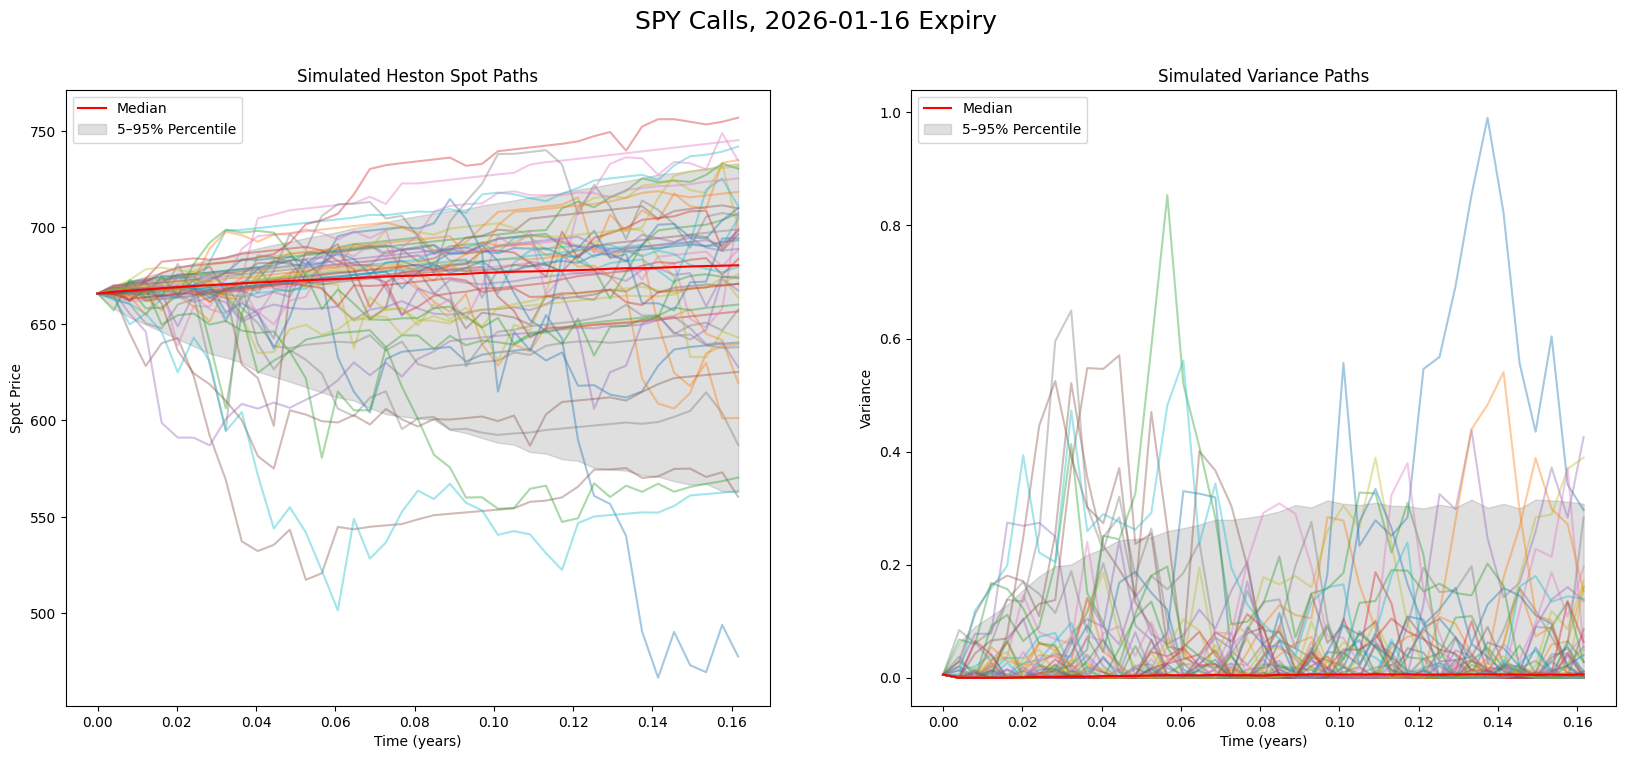

In [9]:
plot_sim_paths(time_grid, S_paths, v_paths, S_path_p05, S_path_p50, S_path_p95, v_path_p05, v_path_p50, v_path_p95, TICKER, EXPIRY, "c")

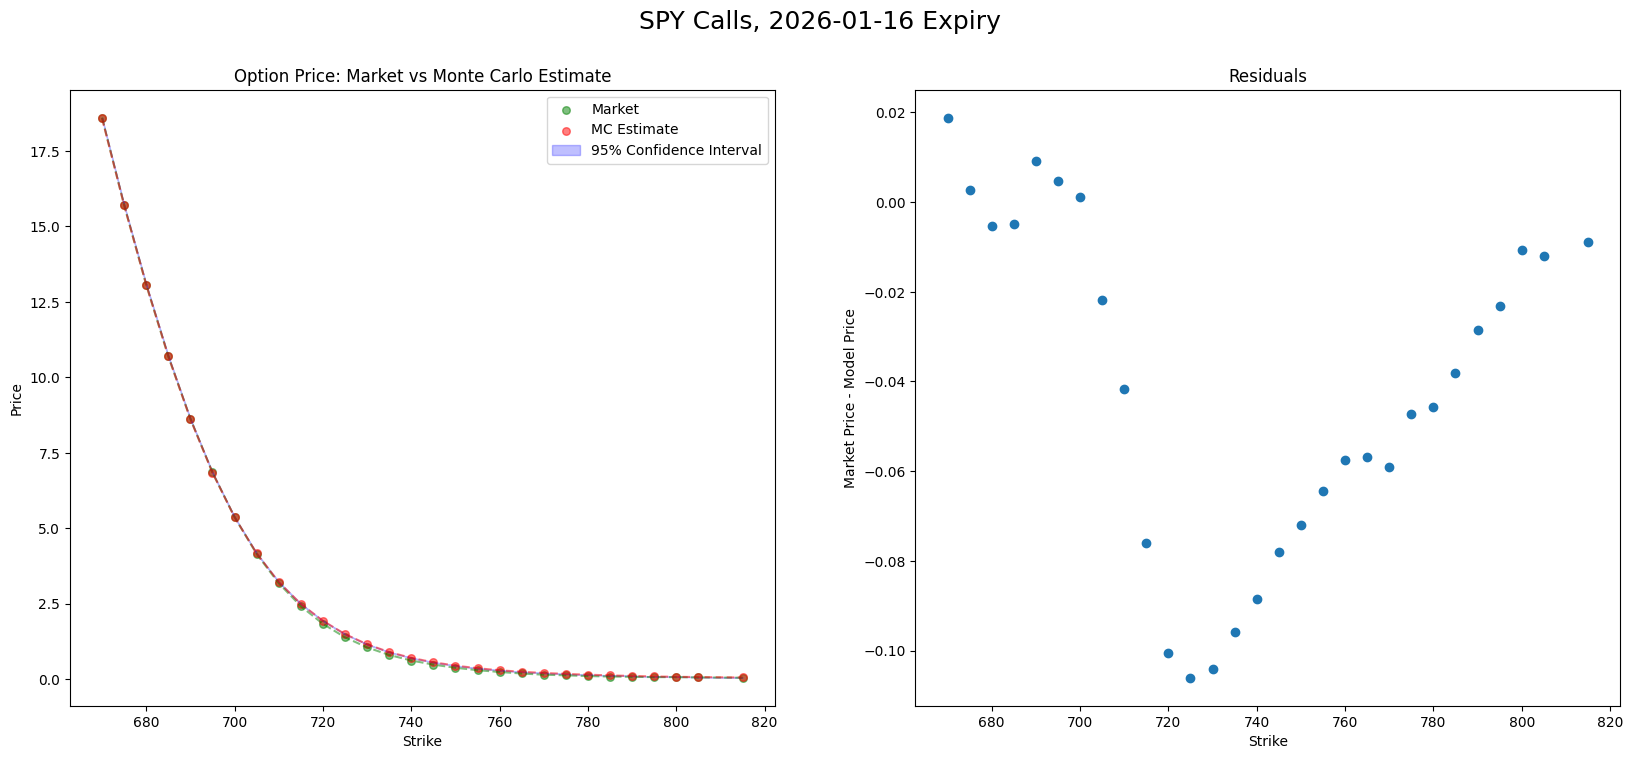

In [10]:
compare_prices(calls_single_exp, TICKER, EXPIRY, "c")

## Single Expiry Puts (2026-01-16)

### Calibrate Heston

In [11]:
# ---------- Calibrate Heston ----------

# Calibration weighting
puts_list_single_exp = build_vanilla_instruments(puts_single_exp, today)
puts_single_exp = bs_price_vega(puts_single_exp, puts_list_single_exp, S_quote, r_curve, q_curve)
puts_single_exp = calibration_weighting(puts_single_exp, LAMBDA_WING)
puts_list_single_exp = build_vanilla_instruments(puts_single_exp, today)

# Fit Heston Model
kappa, theta, sigma, rho, v0 = fit_heston_ls(puts_single_exp, puts_list_single_exp, S_quote, r_curve, q_curve, PARAM_LB, PARAM_UB)
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()
rmse_price = compute_price_rmse(puts_single_exp, puts_list_single_exp, heston_pricing_engine)

# Compute Model Prices & IV
puts_single_exp = model_prices_and_ivs(puts_single_exp, heston_pricing_engine, today, S_quote, r_curve, q_curve)
puts_single_exp = compute_residuals(puts_single_exp)

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f}")
print(f"  theta = {float(theta):.8f}")
print(f"  sigma = {float(sigma):.8f}")
print(f"  rho   = {float(rho):.8f}")
print(f"  v0    = {float(v0):.8f}")
print(f"\nPrice RMSE: {float(rmse_price):.8f}")
print(f"Mean Option Price: {float(np.nanmean(puts_single_exp["mid"])):.8f}")

Calibrated Heston Parameters:
  kappa = 19.42784442
  theta = 0.04163175
  sigma = 4.99999990
  rho   = -0.28819679
  v0    = 0.08778512

Price RMSE: 0.13387824
Mean Option Price: 3.31286885


#### Plots

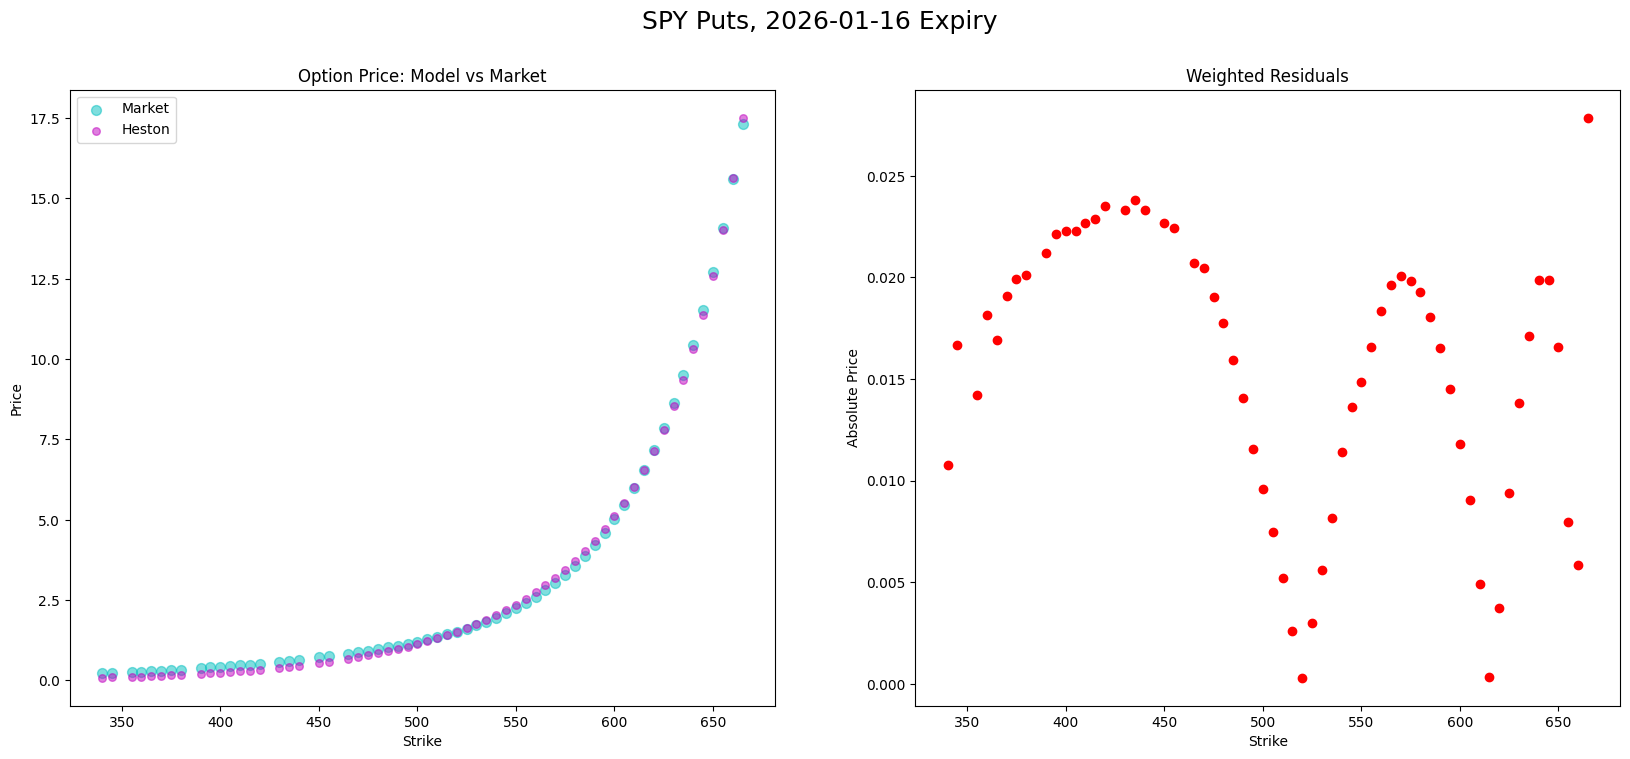

In [12]:
plot_prices(puts_single_exp, TICKER, N_EXP, "p", EXPIRY)

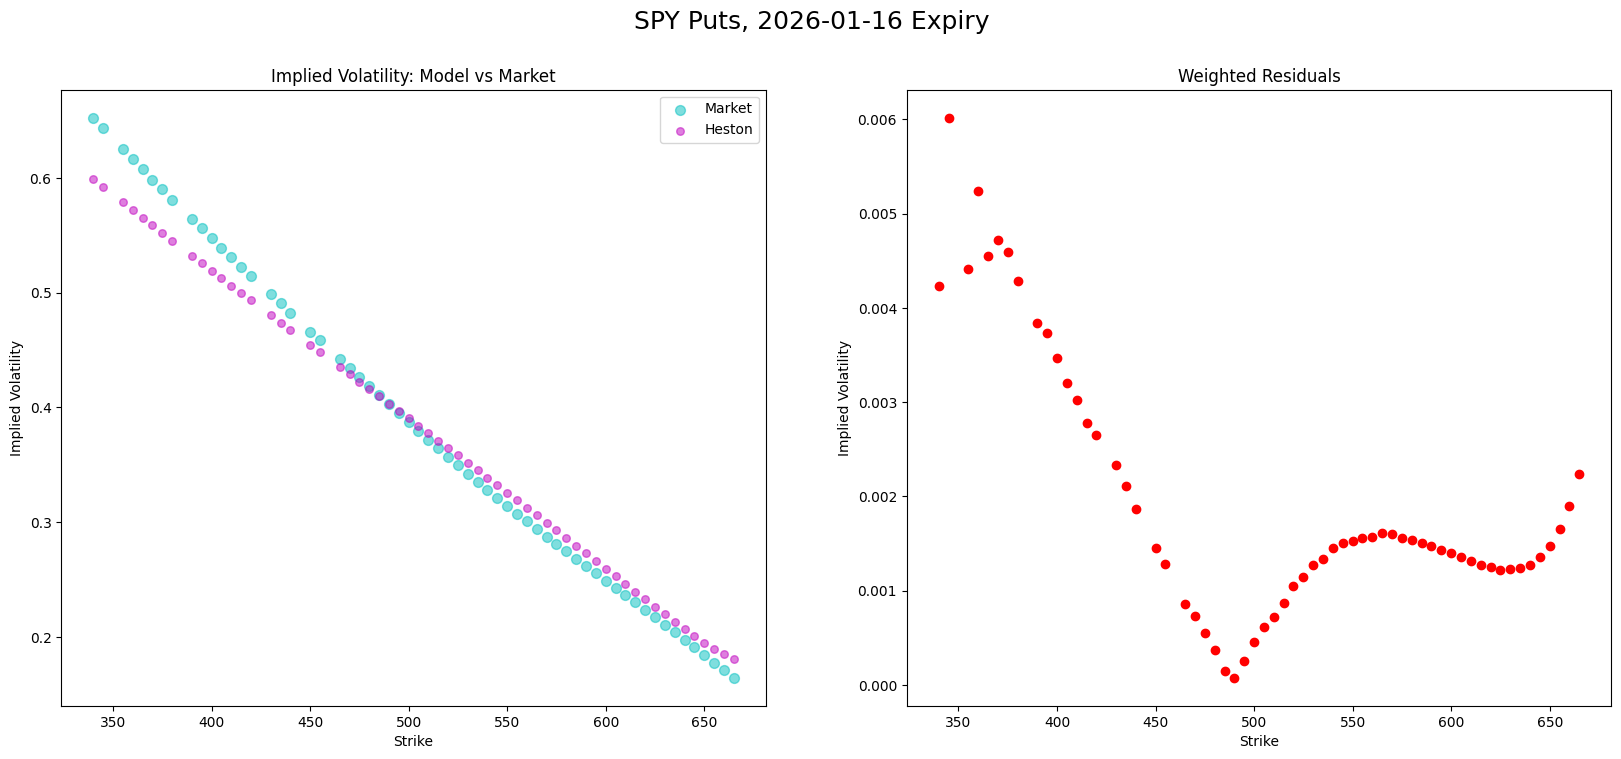

In [13]:
plot_iv(puts_single_exp, TICKER, N_EXP, "p", EXPIRY)

### Simulate Volatility Paths

In [14]:
# ---------- Simulate Volatility Paths from Calibrated Heston ----------

# Simulation horizon
T_sim = float(puts_single_exp["T"].max())

# Trading days to expiry
trading_days_to_exp = int(puts_single_exp["trading_days_to_exp"].max())

# Monte Carlo settings
N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
N_PATHS_MC = 10000                              # number of simulated paths

# Simulate under today’s calibrated risk-neutral Heston dynamics
time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
vol_paths = np.sqrt(v_paths)

# ---------- 5%–95% Quantile Bands ----------

# Spot price paths
S_path_p05 = np.percentile(S_paths, 5, axis = 0)
S_path_p50 = np.percentile(S_paths, 50, axis = 0)
S_path_p95 = np.percentile(S_paths, 95, axis = 0)

# Variance paths
v_path_p05 = np.percentile(v_paths, 5, axis = 0)
v_path_p50 = np.percentile(v_paths, 50, axis = 0)
v_path_p95 = np.percentile(v_paths, 95, axis = 0)

# Volatility paths
vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)

# ---------- Monte Carlo Option Price Estimates & CI ----------

# Simulated spot prices at maturity
S_T = S_paths[:, -1]

price_estimates = []
price_ci_lower = []
price_ci_upper = []

for _, option_row in puts_single_exp.iterrows():
    K = float(option_row["strike"])
    option_type = option_row["type"]
    price_est, est_ci_lower, est_ci_upper = mc_option_price_est(S_T, K, T_sim, r_curve, N_PATHS_MC, option_type[0])
    price_estimates.append(price_est)
    price_ci_lower.append(est_ci_lower)
    price_ci_upper.append(est_ci_upper)

puts_single_exp["mc_price"] = price_estimates
puts_single_exp["ci_lower"] = price_ci_lower
puts_single_exp["ci_upper"] = price_ci_upper

#### Plots

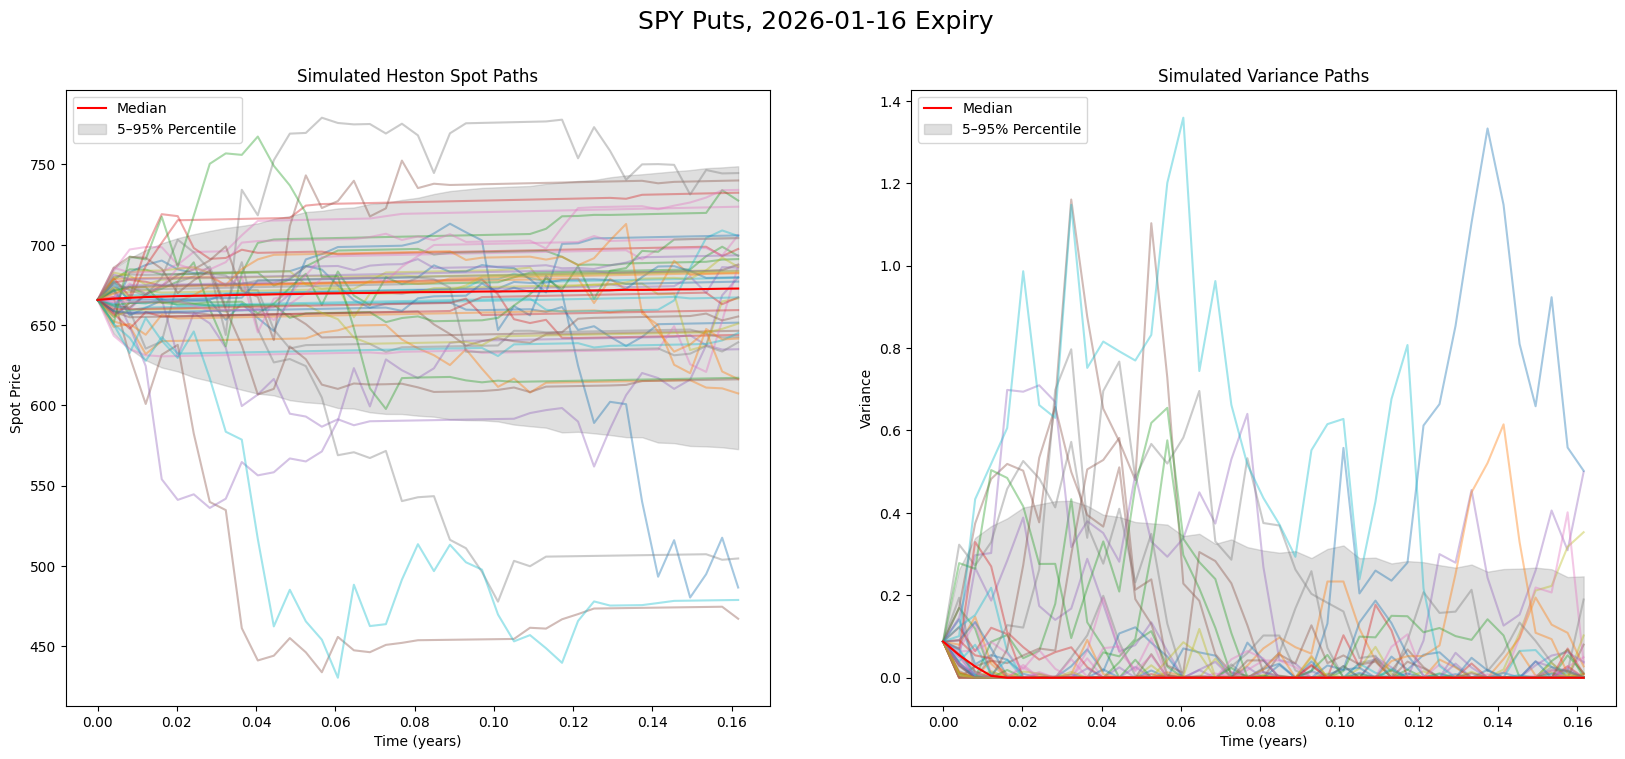

In [15]:
plot_sim_paths(time_grid, S_paths, v_paths, S_path_p05, S_path_p50, S_path_p95, v_path_p05, v_path_p50, v_path_p95, TICKER, EXPIRY, "p")

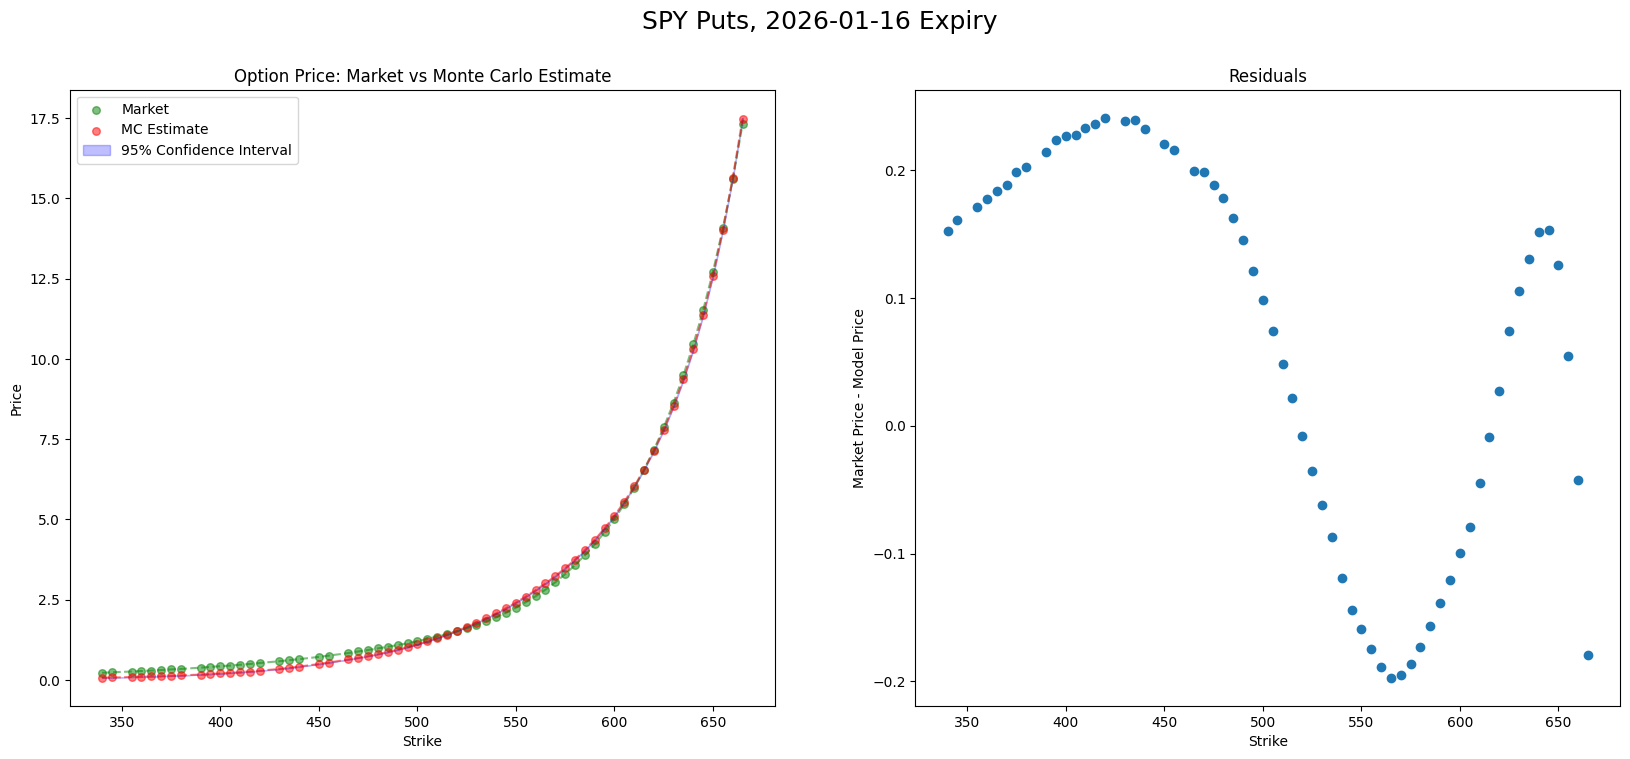

In [16]:
compare_prices(puts_single_exp, TICKER, EXPIRY, "p")

## Single Expiry Options (2026-01-16)

### Calibrate Heston

In [17]:
# ---------- Calibrate Heston ----------

# Calibration weighting
options_list_single_exp = build_vanilla_instruments(chains_single_exp, today)
chains_single_exp = bs_price_vega(chains_single_exp, options_list_single_exp, S_quote, r_curve, q_curve)
chains_single_exp = calibration_weighting(chains_single_exp, LAMBDA_WING)
options_list_single_exp = build_vanilla_instruments(chains_single_exp, today)

# Fit Heston Model
kappa, theta, sigma, rho, v0 = fit_heston_ls(chains_single_exp, options_list_single_exp, S_quote, r_curve, q_curve, PARAM_LB, PARAM_UB)
heston_model, heston_pricing_engine = build_heston_engine(S_quote, r_curve, q_curve, kappa, theta, sigma, rho, v0)
heston_process = heston_model.process()
rmse_price = compute_price_rmse(chains_single_exp, options_list_single_exp, heston_pricing_engine)

# Compute Model Prices & IV
chains_single_exp = model_prices_and_ivs(chains_single_exp, heston_pricing_engine, today, S_quote, r_curve, q_curve)
chains_single_exp = compute_residuals(chains_single_exp)

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa):.8f}")
print(f"  theta = {float(theta):.8f}")
print(f"  sigma = {float(sigma):.8f}")
print(f"  rho   = {float(rho):.8f}")
print(f"  v0    = {float(v0):.8f}")
print(f"\nPrice RMSE: {float(rmse_price):.8f}")
print(f"Mean Option Price: {float(np.nanmean(chains_single_exp["mid"])):.8f}")

Calibrated Heston Parameters:
  kappa = 29.99990453
  theta = 0.02367928
  sigma = 3.91710920
  rho   = -0.63109228
  v0    = 0.13511572

Price RMSE: 0.23716493
Mean Option Price: 3.31922222


#### Plots

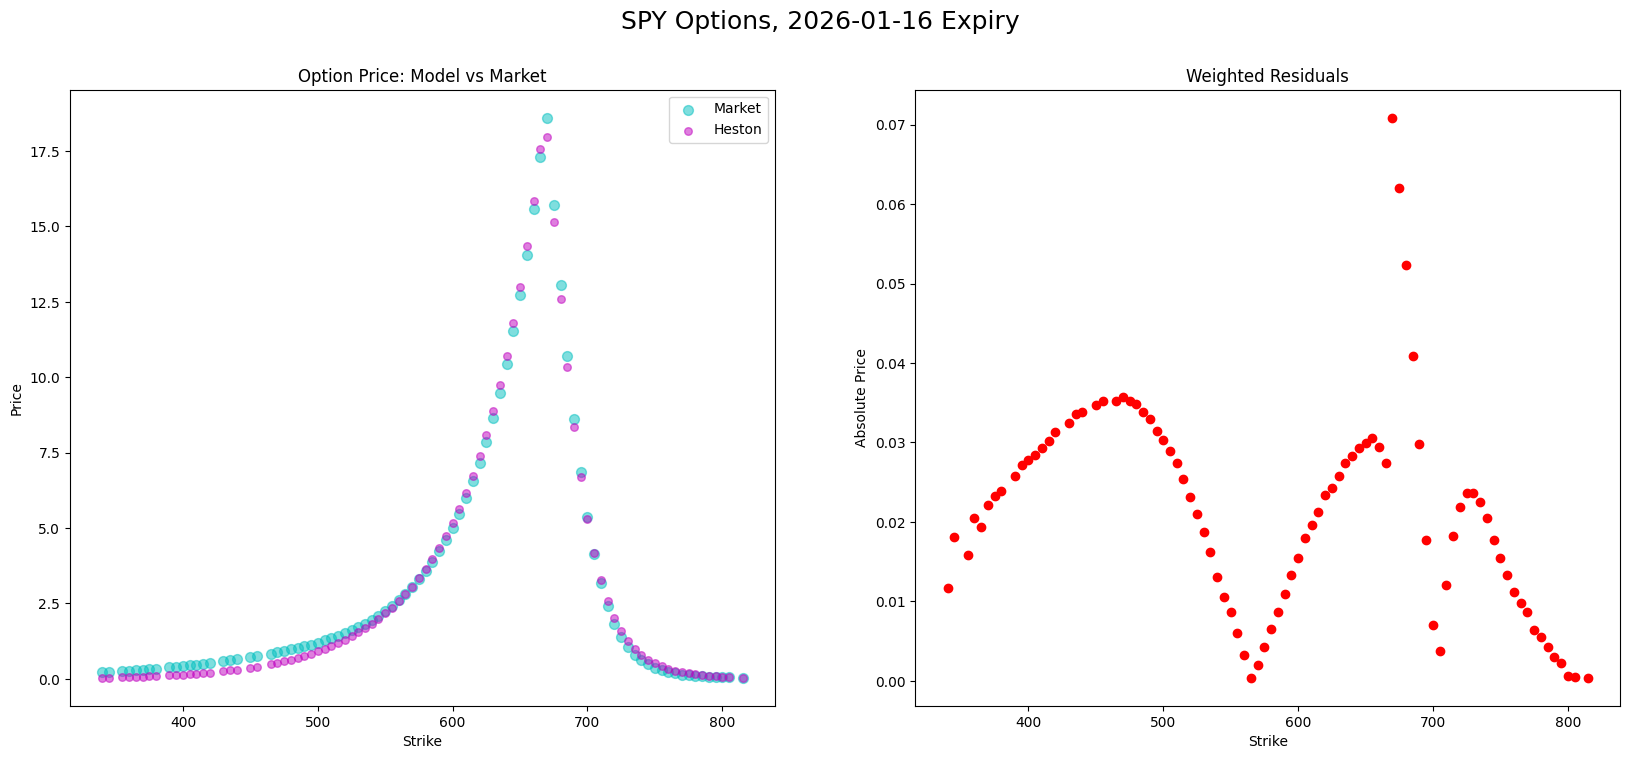

In [18]:
plot_prices(chains_single_exp, TICKER, N_EXP, expiry = EXPIRY)

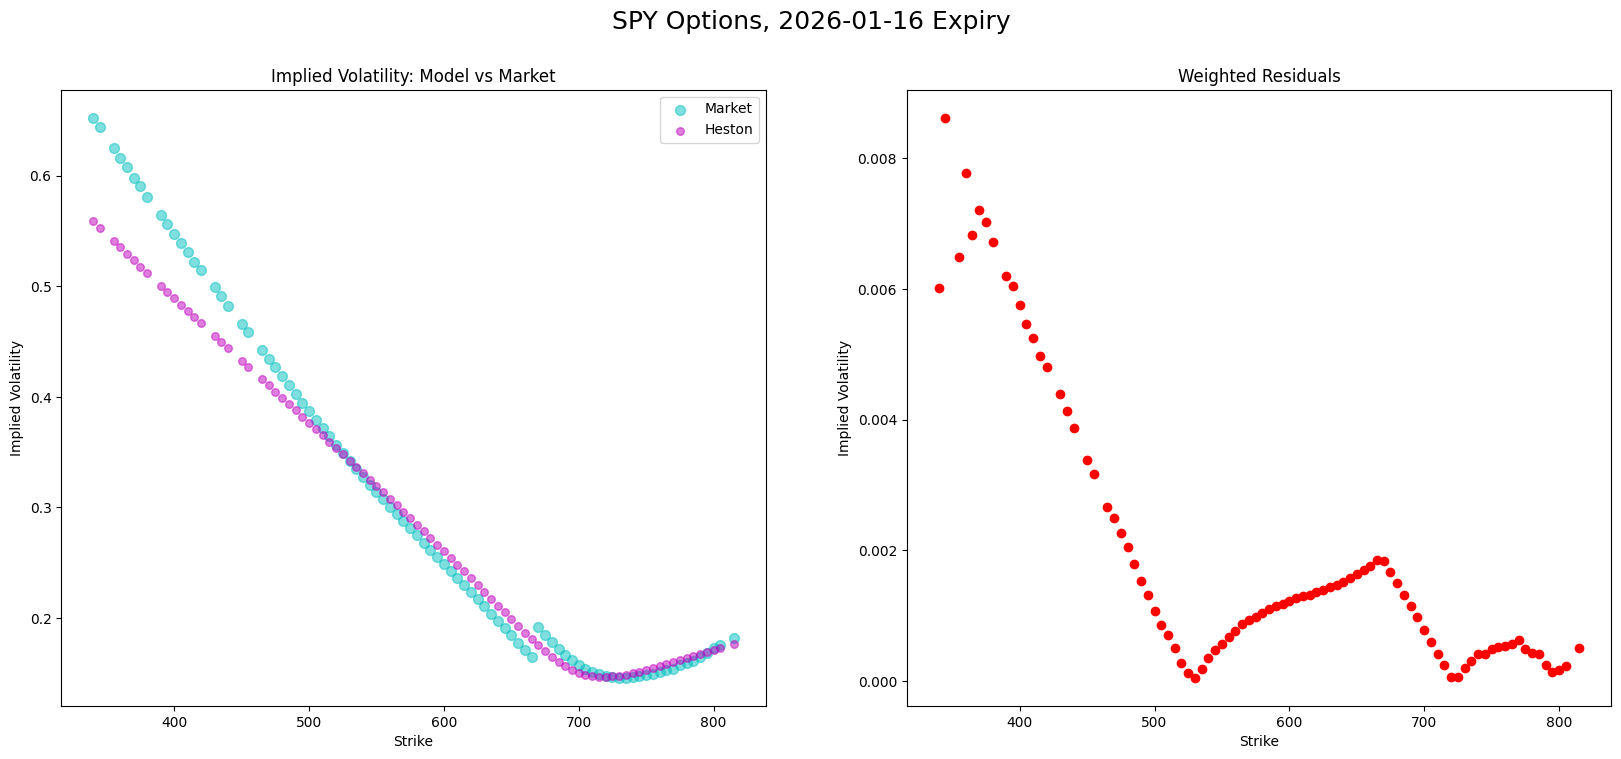

In [19]:
plot_iv(chains_single_exp, TICKER, N_EXP, expiry = EXPIRY)

### Simulate Volatility Paths

In [20]:
# ---------- Simulate Volatility Paths from Calibrated Heston ----------

# Simulation horizon
T_sim = float(chains_single_exp["T"].max())

# Trading days to expiry
trading_days_to_exp = int(chains_single_exp["trading_days_to_exp"].max())

# Monte Carlo settings
N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
N_PATHS_MC = 10000                              # number of simulated paths

# Simulate under today’s calibrated risk-neutral Heston dynamics
time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
vol_paths = np.sqrt(v_paths)

# ---------- 5%–95% Quantile Bands ----------

# Spot price paths
S_path_p05 = np.percentile(S_paths, 5, axis = 0)
S_path_p50 = np.percentile(S_paths, 50, axis = 0)
S_path_p95 = np.percentile(S_paths, 95, axis = 0)

# Variance paths
v_path_p05 = np.percentile(v_paths, 5, axis = 0)
v_path_p50 = np.percentile(v_paths, 50, axis = 0)
v_path_p95 = np.percentile(v_paths, 95, axis = 0)

# Volatility paths
vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)

# ---------- Monte Carlo Option Price Estimates & CI ----------

# Simulated spot prices at maturity
S_T = S_paths[:, -1]

price_estimates = []
price_ci_lower = []
price_ci_upper = []

for _, option_row in chains_single_exp.iterrows():
    K = float(option_row["strike"])
    option_type = option_row["type"]
    price_est, est_ci_lower, est_ci_upper = mc_option_price_est(S_T, K, T_sim, r_curve, N_PATHS_MC, option_type[0])
    price_estimates.append(price_est)
    price_ci_lower.append(est_ci_lower)
    price_ci_upper.append(est_ci_upper)

chains_single_exp["mc_price"] = price_estimates
chains_single_exp["ci_lower"] = price_ci_lower
chains_single_exp["ci_upper"] = price_ci_upper

#### Plots

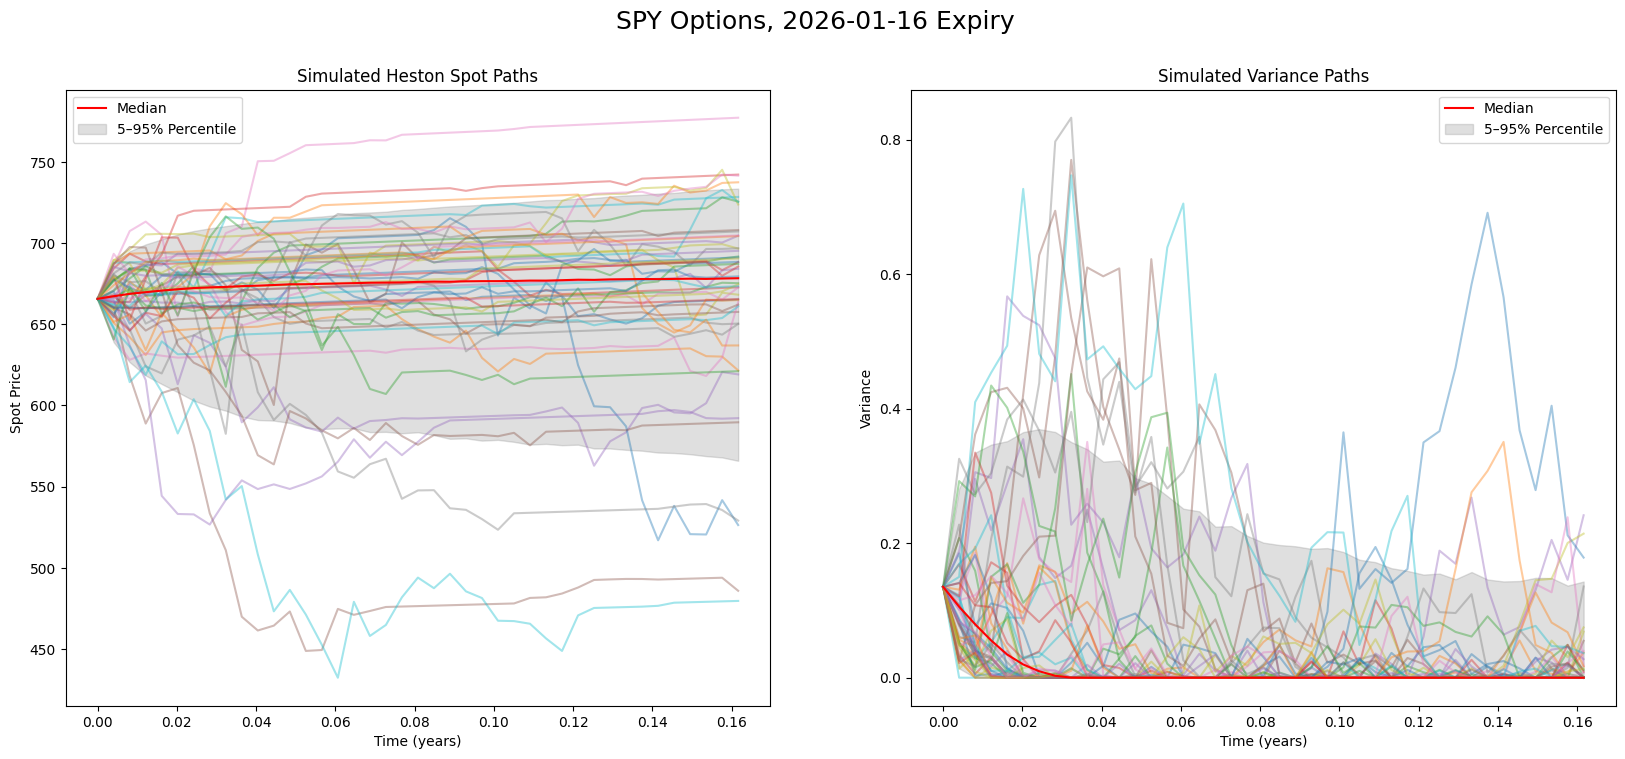

In [21]:
plot_sim_paths(time_grid, S_paths, v_paths, S_path_p05, S_path_p50, S_path_p95, v_path_p05, v_path_p50, v_path_p95, TICKER, EXPIRY)

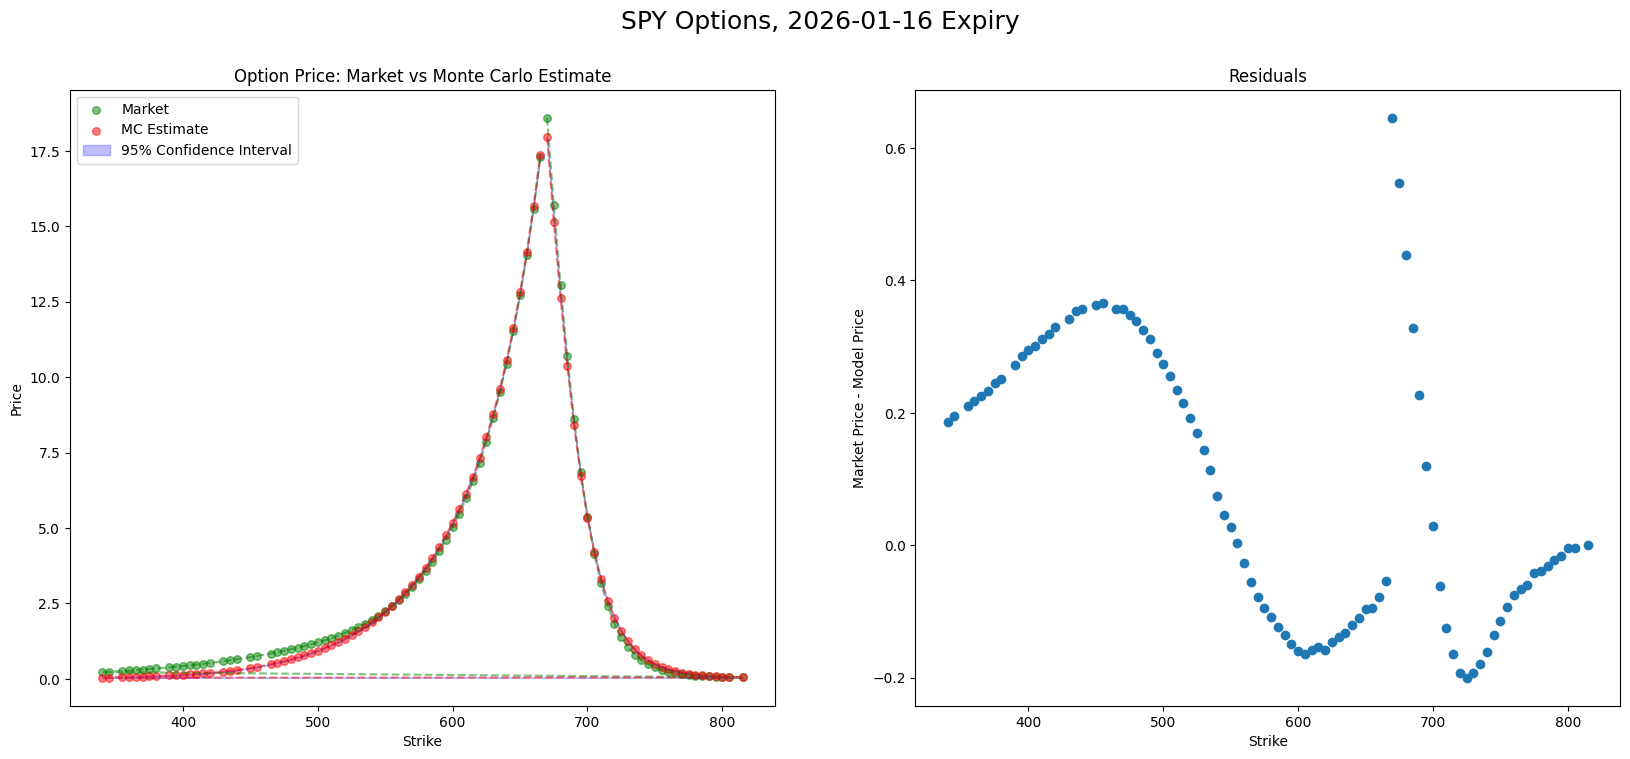

In [22]:
compare_prices(chains_single_exp, TICKER, EXPIRY)

## All Options

### Calibrate Model

In [ ]:
# ---------- Calibrate Heston ----------

# Calibration weighting
options_list_all = build_vanilla_instruments(all_chains, today)
all_chains = bs_price_vega(all_chains, options_list_all, S_quote, r_curve, q_curve)
all_chains = calibration_weighting(all_chains, LAMBDA_WING)
options_list_all = build_vanilla_instruments(all_chains, today)

# Fit Heston Model
kappa_all, theta_all, sigma_all, rho_all, v0_all = fit_heston_ls(all_chains, options_list_all, S_quote, r_curve, q_curve, PARAM_LB, PARAM_UB)
heston_model_all, heston_pricing_engine_all = build_heston_engine(S_quote, r_curve, q_curve, kappa_all, theta_all, sigma_all, rho_all, v0_all)
heston_process_all = heston_model_all.process()
rmse_price_all = compute_price_rmse(all_chains, options_list_all, heston_pricing_engine_all)

# Compute Model Prices & IV
all_chains = model_prices_and_ivs(all_chains, heston_pricing_engine_all, today, S_quote, r_curve, q_curve)
all_chains = compute_residuals(all_chains)

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa_all):.8f}")
print(f"  theta = {float(theta_all):.8f}")
print(f"  sigma = {float(sigma_all):.8f}")
print(f"  rho   = {float(rho_all):.8f}")
print(f"  v0    = {float(v0_all):.8f}")
print(f"\nPrice RMSE: {float(rmse_price_all):.8f}")
print(f"Mean Option Price: {float(np.nanmean(chains_df["mid"])):.8f}")

### Simulate Volatility Paths

### All Expiries

In [10]:
all_chains = chains_df.copy()
# TODO: GRIDDING?

# ---------- Calibrate Heston ----------

# Calibration weighting
options_list_all = build_vanilla_instruments(all_chains, today)
all_chains = bs_price_vega(all_chains, options_list_all, S_quote, r_curve, q_curve)
all_chains = calibration_weighting(all_chains, LAMBDA_WING)
options_list_all = build_vanilla_instruments(all_chains, today)

# Fit Heston Model
kappa_all, theta_all, sigma_all, rho_all, v0_all = fit_heston_ls(all_chains, options_list_all, S_quote, r_curve, q_curve, PARAM_LB, PARAM_UB)
heston_model_all, heston_pricing_engine_all = build_heston_engine(S_quote, r_curve, q_curve, kappa_all, theta_all, sigma_all, rho_all, v0_all)
heston_process_all = heston_model_all.process()
rmse_price_all = compute_price_rmse(all_chains, options_list_all, heston_pricing_engine_all)

# Compute Model Prices & IV
all_chains = model_prices_and_ivs(all_chains, heston_pricing_engine_all, today, S_quote, r_curve, q_curve)
all_chains = compute_residuals(all_chains)

# ---------- Fitted Parameters ----------

print("Calibrated Heston Parameters:")
print(f"  kappa = {float(kappa_all):.8f}")
print(f"  theta = {float(theta_all):.8f}")
print(f"  sigma = {float(sigma_all):.8f}")
print(f"  rho   = {float(rho_all):.8f}")
print(f"  v0    = {float(v0_all):.8f}")
print(f"\nPrice RMSE: {float(rmse_price_all):.8f}")
print(f"Mean Option Price: {float(np.nanmean(chains_df["mid"])):.8f}")

Calibrated Heston Parameters:
  kappa = 9.27870729
  theta = 0.04666398
  sigma = 1.91850480
  rho   = -0.66121196
  v0    = 0.04665871

Price RMSE: 0.37600561
Mean Option Price: 5.15884567


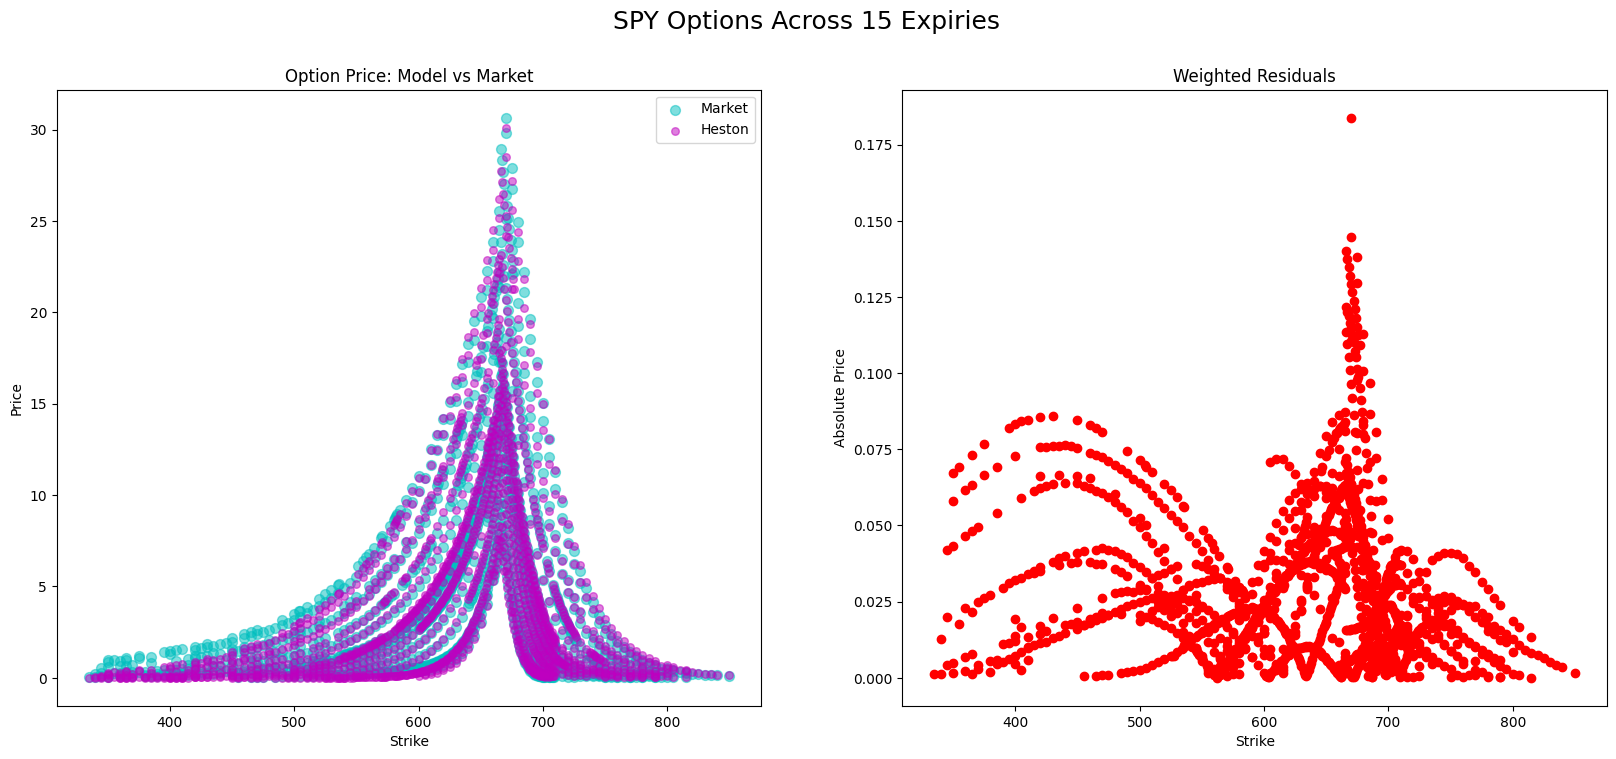

In [11]:
plot_prices(all_chains, TICKER, N_EXP)

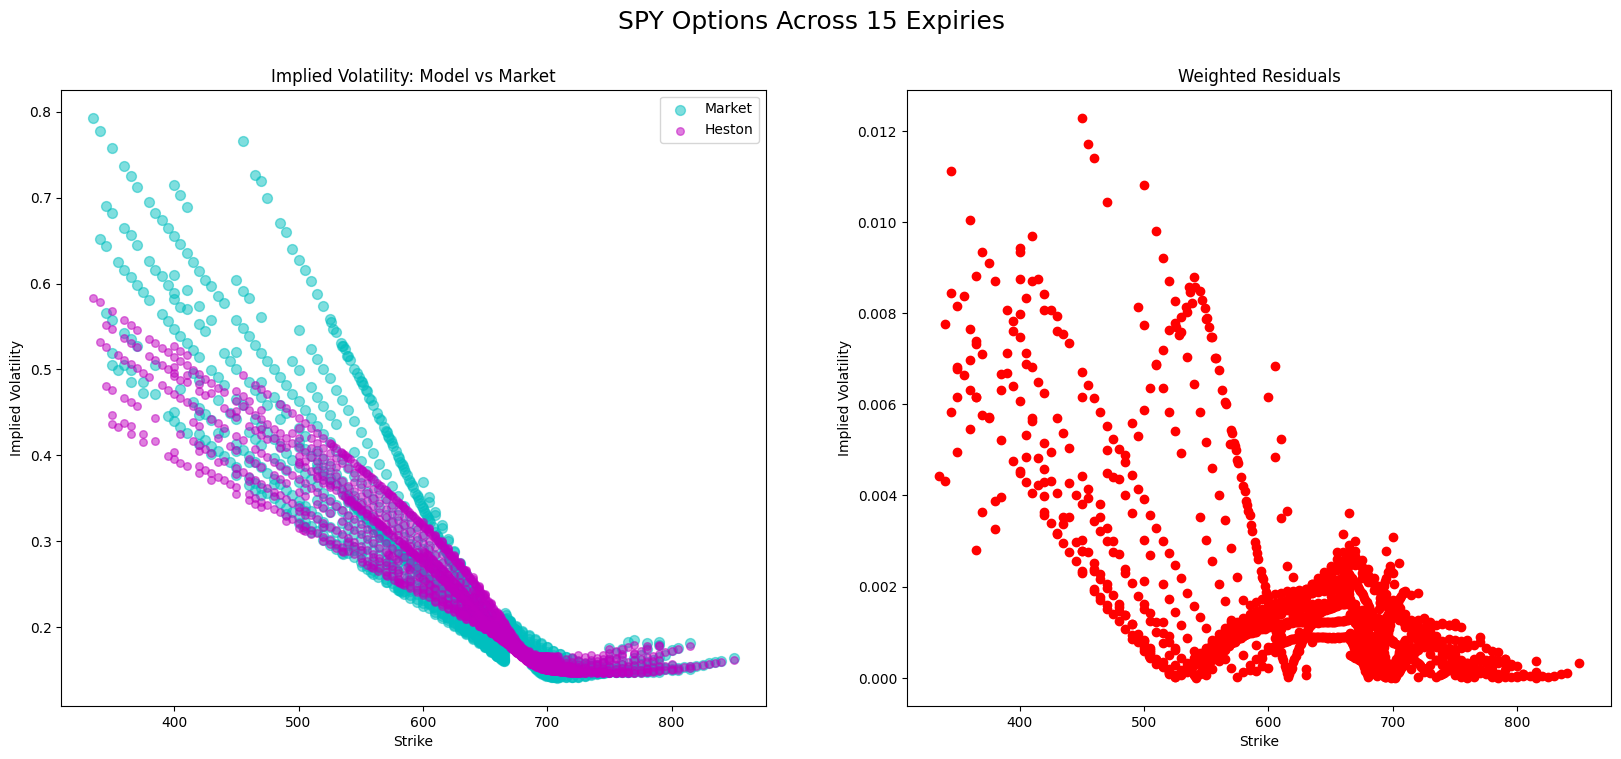

In [12]:
plot_iv(all_chains, TICKER, N_EXP)

In [ ]:
# ---------- Simulate Volatility Paths from Calibrated Heston ----------

# Simulation horizon
T_sim = float(puts_single_exp["T"].max())

# Trading days to expiry
trading_days_to_exp = int(puts_single_exp["trading_days_to_exp"].max())

# Monte Carlo settings
N_STEPS_MC = int(trading_days_to_exp)           # e.g. daily steps over the horizon (1 year = 252 steps)
N_PATHS_MC = 10000                              # number of simulated paths

# Simulate under today’s calibrated risk-neutral Heston dynamics
time_grid, S_paths, v_paths = simulate_heston_paths(heston_process, T_sim, N_STEPS_MC, N_PATHS_MC)
vol_paths = np.sqrt(v_paths)

# ---------- 5%–95% Quantile Bands ----------

# Spot price paths
S_path_p05 = np.percentile(S_paths, 5, axis = 0)
S_path_p50 = np.percentile(S_paths, 50, axis = 0)
S_path_p95 = np.percentile(S_paths, 95, axis = 0)

# Variance paths
v_path_p05 = np.percentile(v_paths, 5, axis = 0)
v_path_p50 = np.percentile(v_paths, 50, axis = 0)
v_path_p95 = np.percentile(v_paths, 95, axis = 0)

# Volatility paths
vol_path_p05 = np.percentile(vol_paths, 5, axis = 0)
vol_path_p50 = np.percentile(vol_paths, 50, axis = 0)
vol_path_p95 = np.percentile(vol_paths, 95, axis = 0)

# ---------- Monte Carlo Option Price Estimates & CI ----------

# Simulated spot prices at maturity
S_T = S_paths[:, -1]

price_estimates = []
price_ci_lower = []
price_ci_upper = []

for _, option_row in puts_single_exp.iterrows():
    K = float(option_row["strike"])
    option_type = option_row["type"]
    price_est, est_ci_lower, est_ci_upper = mc_option_price_est(S_T, K, T_sim, r_curve, N_PATHS_MC, option_type[0])
    price_estimates.append(price_est)
    price_ci_lower.append(est_ci_lower)
    price_ci_upper.append(est_ci_upper)

puts_single_exp["mc_price"] = price_estimates
puts_single_exp["ci_lower"] = price_ci_lower
puts_single_exp["ci_upper"] = price_ci_upper